# Step 1: Data Extraction, Cleaning & EDA
## Predictive Microbiology Toolkit for RTE Seafood Safety

---
> ⚠️ **Execution Order:** Run notebooks in sequence: **Step 1 → Step 2 → Step 3 → Step 4**  
> Step 1 generates `outputs/aeromonas_kinetics_master.csv`.  
> Steps 2, 3, and 4 will fail without this file.

---

**Author:** Hyejeong Lee  
**Data source:** Lee et al. (2023), *Int. J. Food Microbiology* 384:109985  
**Paper:** The effect of food processing factors on the growth kinetics of *Aeromonas* strains isolated from ready-to-eat seafood  

---

## Project Purpose

This project extends Lee et al. (2023) beyond its original Ratkowsky mechanistic model
using machine learning and explainable AI (SHAP):

| Step | What | Why |
|------|------|-----|
| **Step 1 (this notebook)** | Data extraction, cleaning, EDA, Ratkowsky reproduction | Establish the biological baseline and validate data fidelity |
| **Step 2** | ML modeling — GPR + RF + XGBoost under LOSO cross-validation | Quantify whether multi-variable ML improves on the temperature-only Ratkowsky model |
| **Step 3** | SHAP analysis on RandomForest | Identify which hurdle factors drive μmax and how they interact |
| **Step 4** | Streamlit app | Deploy as an interactive food safety decision-support tool |

**Core thesis:** A Bayesian model (GPR) provides the best μmax prediction accuracy (LOSO R²=0.878)
with calibrated uncertainty bounds. A tree-based model (RandomForest, R²=0.835) enables
SHAP interpretability. Together they form a dual-purpose pipeline that neither a mechanistic
model nor a single ML model can replicate alone.

---

### What this notebook covers
1. **Data entry & structuring** — manually curated from Supplementary Tables A–D
2. **Data validation** — sanity checks against published results
3. **Exploratory Data Analysis (EDA)** — visualise all kinetic parameters across conditions
4. **Secondary model reproduction** — reproduce the Ratkowsky square-root model from the paper
5. **ComBase integration plan** — how to download and merge public data to expand sample size

### Dataset overview
| Factor | Levels |
|---|---|
| Strains | 8 (*Aeromonas* spp., 7 species) |
| Temperature | 4°C, 8°C, 15°C |
| NaCl | 0 (baseline), 1.5%, 3.0%, 4.5%, 6.0% |
| PCS VTABB | 0, 0.026%, 0.13%, 2.6% |
| PCS JJT01 | 0, 0.026%, 0.13%, 2.6% |
| Media | TSB, SJ (salmon juice) |
| Response variables | μmax (h⁻¹), lag phase (h), Ymax (log CFU/g) |


---
## 0. Setup

In [1]:
# Install required packages (run once)
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn openpyxl requests

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import os

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = sns.color_palette('tab10', 8)

# ── Output directory ─────────────────────────────────────────────────────────
OUT_DIR = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Strain ordering & consistent color map ───────────────────────────────────
STRAINS_ORDER = [
    'A_media', 'A_bestiarum', 'A_piscicola', 'A_salmonicida_SU2',
    'A_salmonicida_Nr21', 'A_hydrophila', 'A_dhakensis', 'A_caviae'
]
LABELS = {
    'A_media':            'A. media',
    'A_bestiarum':        'A. bestiarum',
    'A_piscicola':        'A. piscicola',
    'A_salmonicida_SU2':  'A. salmonicida SU2',
    'A_salmonicida_Nr21': 'A. salmonicida Nr.21',
    'A_hydrophila':       'A. hydrophila',
    'A_dhakensis':        'A. dhakensis',
    'A_caviae':           'A. caviae',
}
SC = {s: PALETTE[i] for i, s in enumerate(STRAINS_ORDER)}

print('Setup complete ✓')
print(f'Strains: {len(STRAINS_ORDER)}  |  OUT_DIR: {OUT_DIR}')


Setup complete ✓
Strains: 8  |  OUT_DIR: outputs


---
## 1. Data Entry

Values transcribed from Supplementary Material Tables A–D (Lee et al. 2023).  
**NL** = no lag (set to 0), **NG** = no growth (excluded), **NA** = no asymptote (Ymax = NaN).

Strain abbreviations:
- `A_media`, `A_bestiarum`, `A_piscicola`, `A_salmonicida_SU2`, `A_salmonicida_Nr21`
- `A_hydrophila`, `A_dhakensis`, `A_caviae`

In [2]:
# ============================================================
# TABLE A — Temperature × Media
# Columns: strain, temperature_C, medium,
#          mu_max, lag_h, ymax, r2, se
# NL (no lag) → 0 ; NG (no growth) → row excluded
# ============================================================

table_A_rows = [
    # A. media
    ('A_media',           4,  'SJ',  0.019, 31.6,  8.81, 0.94, 0.203),
    ('A_media',           8,  'SJ',  0.032,  5.94, 8.91, 0.98, 0.103),
    ('A_media',          15,  'SJ',  0.078,  0.8,  8.92, 0.99, 0.090),
    ('A_media',           4,  'TSB', 0.025, 13.08, 8.64, 0.99, 0.049),
    ('A_media',           8,  'TSB', 0.051,  5.17, 8.79, 0.99, 0.071),
    ('A_media',          15,  'TSB', 0.091,  4.36, 9.03, 0.97, 0.133),
    # A. bestiarum
    ('A_bestiarum',       4,  'SJ',  0.021, 14.14, 8.95, 0.98, 0.111),
    ('A_bestiarum',       8,  'SJ',  0.030,  1.13, 9.00, 0.98, 0.120),
    ('A_bestiarum',      15,  'SJ',  0.075,  0.69, 9.12, 0.99, 0.065),
    ('A_bestiarum',       4,  'TSB', 0.026,  9.03, 8.90, 0.99, 0.078),
    ('A_bestiarum',       8,  'TSB', 0.045,  3.46, 9.10, 0.99, 0.062),
    ('A_bestiarum',      15,  'TSB', 0.082,  1.49, 9.12, 0.99, 0.059),
    # A. piscicola
    ('A_piscicola',       4,  'SJ',  0.019, 18.11, 8.87, 0.99, 0.082),
    ('A_piscicola',       8,  'SJ',  0.026,  2.04, 8.90, 0.99, 0.069),
    ('A_piscicola',      15,  'SJ',  0.057,  0.0,  9.03, 0.97, 0.137),  # NL → 0
    ('A_piscicola',       4,  'TSB', 0.026,  9.88, 8.91, 0.99, 0.066),
    ('A_piscicola',       8,  'TSB', 0.044,  4.91, 9.06, 1.00, 0.051),
    ('A_piscicola',      15,  'TSB', 0.103,  5.34, 9.11, 0.98, 0.107),
    # A. salmonicida SU2
    ('A_salmonicida_SU2', 4,  'SJ',  0.014, 16.06, 8.83, 0.98, 0.122),
    ('A_salmonicida_SU2', 8,  'SJ',  0.024,  3.30, 9.05, 0.99, 0.082),
    ('A_salmonicida_SU2',15,  'SJ',  0.043,  0.0,  8.96, 0.97, 0.133),  # NL → 0
    ('A_salmonicida_SU2', 4,  'TSB', 0.024,  3.59, 9.00, 1.00, 0.044),
    ('A_salmonicida_SU2', 8,  'TSB', 0.046,  3.65, 9.07, 0.99, 0.066),
    ('A_salmonicida_SU2',15,  'TSB', 0.096,  3.76, 9.13, 0.97, 0.135),
    # A. salmonicida Nr.21
    ('A_salmonicida_Nr21',4,  'SJ',  0.016,  4.07, 9.10, 0.98, 0.107),
    ('A_salmonicida_Nr21',8,  'SJ',  0.026,  6.18, 9.08, 1.00, 0.054),
    ('A_salmonicida_Nr21',15, 'SJ',  0.053,  0.0,  8.98, 0.98, 0.127),  # NL → 0
    ('A_salmonicida_Nr21',4,  'TSB', 0.021,  0.0,  8.93, 0.99, 0.059),  # NL → 0
    ('A_salmonicida_Nr21',8,  'TSB', 0.038,  2.80, 9.02, 0.99, 0.064),
    ('A_salmonicida_Nr21',15, 'TSB', 0.088,  2.52, 9.03, 0.99, 0.082),
    # A. hydrophila  (NG at 4°C in both media)
    ('A_hydrophila',      8,  'SJ',  0.028, 22.64, 8.79, 0.99, 0.052),
    ('A_hydrophila',     15,  'SJ',  0.058,  0.8,  8.95, 0.99, 0.084),
    ('A_hydrophila',      8,  'TSB', 0.038, 13.62, 8.80, 0.99, 0.030),
    ('A_hydrophila',     15,  'TSB', 0.096,  3.11, 9.07, 0.98, 0.110),
    # A. dhakensis  (NG at 4°C in both media)
    ('A_dhakensis',       8,  'SJ',  0.020, 10.74, 8.76, 0.98, 0.093),
    ('A_dhakensis',      15,  'SJ',  0.080,  0.62, 8.98, 0.99, 0.106),
    ('A_dhakensis',       8,  'TSB', 0.033,  8.80, 8.71, 0.99, 0.041),
    ('A_dhakensis',      15,  'TSB', 0.112,  7.80, 9.06, 0.95, 0.171),
    # A. caviae  (NG at 4°C both media; NG at 8°C SJ)
    ('A_caviae',         15,  'SJ',  0.064,  0.53, 8.92, 0.98, 0.113),
    ('A_caviae',          8,  'TSB', 0.035,  6.36, 8.81, 0.96, 0.042),
    ('A_caviae',         15,  'TSB', 0.082,  0.0,  8.88, 0.97, 0.131),  # NL → 0
]

cols_kinetics = ['strain', 'temperature_C', 'medium', 'mu_max', 'lag_h', 'ymax', 'r2', 'se']
df_A = pd.DataFrame(table_A_rows, columns=cols_kinetics)
df_A['experiment'] = 'Temperature'
df_A['NaCl_pct']  = 0.0
df_A['PCS_type']  = np.nan
df_A['PCS_conc_pct'] = 0.0

print(f'Table A: {len(df_A)} rows')
df_A.head()

Table A: 41 rows


,strain,temperature_C,medium,mu_max,lag_h,ymax,r2,se,experiment,NaCl_pct,PCS_type,PCS_conc_pct
0,A_media,4,SJ,0.019,31.60,8.81,0.94,0.203,Temperature,0.0,NaN,0.0
1,A_media,8,SJ,0.032,5.94,8.91,0.98,0.103,Temperature,0.0,NaN,0.0
2,A_media,15,SJ,0.078,0.80,8.92,0.99,0.090,Temperature,0.0,NaN,0.0
3,A_media,4,TSB,0.025,13.08,8.64,0.99,0.049,Temperature,0.0,NaN,0.0
4,A_media,8,TSB,0.051,5.17,8.79,0.99,0.071,Temperature,0.0,NaN,0.0


In [4]:
# ============================================================
# TABLE B — NaCl × Temperature  (medium = TSB)
# ============================================================

table_B_rows = [
    # --- 4°C ---
    ('A_media',            4,  1.5, 0.018, 18.93, 8.77, 0.96, 0.135),
    ('A_media',            4,  3.0, 0.009, 99.92, 8.52, 0.94, 0.135),
    ('A_bestiarum',        4,  1.5, 0.022, 20.46, 8.91, 1.00, 0.052),
    ('A_bestiarum',        4,  3.0, 0.009, 39.77, 8.50, 0.97, 0.094),
    ('A_piscicola',        4,  1.5, 0.025, 20.27, 8.92, 1.00, 0.047),
    ('A_piscicola',        4,  3.0, 0.013, 26.96, 8.53, 0.98, 0.087),
    ('A_salmonicida_SU2',  4,  1.5, 0.023, 10.58, 8.92, 1.00, 0.031),
    ('A_salmonicida_SU2',  4,  3.0, 0.013, 36.60, 8.75, 0.99, 0.073),
    ('A_salmonicida_Nr21', 4,  1.5, 0.024, 19.61, 8.83, 0.99, 0.066),
    ('A_salmonicida_Nr21', 4,  3.0, 0.013, 54.02, 8.63, 0.99, 0.082),
    # --- 8°C --- (NG at 4.5% and 6.0% for all strains → excluded)
    ('A_media',            8,  1.5, 0.043, 18.20, 8.75, 1.00, 0.042),
    ('A_media',            8,  3.0, 0.036, 35.56, 8.80, 0.99, 0.063),
    ('A_bestiarum',        8,  1.5, 0.039,  5.58, 9.03, 1.00, 0.034),
    ('A_bestiarum',        8,  3.0, 0.026, 16.17, 8.87, 0.98, 0.324),
    ('A_piscicola',        8,  1.5, 0.042,  4.95, 9.01, 0.99, 0.056),
    ('A_piscicola',        8,  3.0, 0.026, 12.55, 8.95, 0.99, 0.080),
    ('A_salmonicida_SU2',  8,  1.5, 0.039,  2.52, 9.00, 1.00, 0.044),
    ('A_salmonicida_SU2',  8,  3.0, 0.030, 16.84, 9.00, 0.99, 0.058),
    ('A_salmonicida_Nr21', 8,  1.5, 0.037,  7.35, 8.97, 0.94, 0.152),
    ('A_salmonicida_Nr21', 8,  3.0, 0.025,  6.93, 8.93, 0.99, 0.058),
    ('A_hydrophila',       8,  1.5, 0.028,  9.30, 8.80, 0.99, 0.058),
    ('A_hydrophila',       8,  3.0, 0.020, 36.89, 8.69, 0.97, 0.097),
    ('A_dhakensis',        8,  1.5, 0.027, 13.90, 8.77, 0.99, 0.065),
    ('A_dhakensis',        8,  3.0, 0.013, 48.47,  np.nan, 0.95, 0.078),  # NA
    ('A_caviae',           8,  1.5, 0.026,  3.25, 8.81, 1.00, 0.045),
    ('A_caviae',           8,  3.0, 0.022, 24.76, 8.75, 0.96, 0.112),
]

cols_B = ['strain', 'temperature_C', 'NaCl_pct', 'mu_max', 'lag_h', 'ymax', 'r2', 'se']
df_B = pd.DataFrame(table_B_rows, columns=cols_B)
df_B['experiment'] = 'NaCl'
df_B['medium']     = 'TSB'
df_B['PCS_type']   = np.nan
df_B['PCS_conc_pct'] = 0.0

print(f'Table B: {len(df_B)} rows')
df_B.head()

Table B: 26 rows


,strain,temperature_C,NaCl_pct,mu_max,lag_h,ymax,r2,se,experiment,medium,PCS_type,PCS_conc_pct
0,A_media,4,1.5,0.018,18.93,8.77,0.96,0.135,NaCl,TSB,NaN,0.0
1,A_media,4,3.0,0.009,99.92,8.52,0.94,0.135,NaCl,TSB,NaN,0.0
2,A_bestiarum,4,1.5,0.022,20.46,8.91,1.00,0.052,NaCl,TSB,NaN,0.0
3,A_bestiarum,4,3.0,0.009,39.77,8.50,0.97,0.094,NaCl,TSB,NaN,0.0
4,A_piscicola,4,1.5,0.025,20.27,8.92,1.00,0.047,NaCl,TSB,NaN,0.0


In [5]:
# ============================================================
# TABLE C — PCS VTABB × Temperature  (medium = TSB)
# ============================================================

table_C_rows = [
    # --- 4°C ---
    ('A_media',            4,  0.026, 0.018,  0.0,  8.82, 0.99, 0.277),   # NL → 0
    # A_media 0.13% → NG
    ('A_bestiarum',        4,  0.026, 0.021,  6.23, 9.13, 0.99, 0.053),
    # A_bestiarum 0.13% → NG
    ('A_piscicola',        4,  0.026, 0.023,  1.38, 9.05, 0.99, 0.063),
    ('A_piscicola',        4,  0.13,  0.017, 89.37, 8.98, 0.94, 0.157),
    ('A_salmonicida_SU2',  4,  0.026, 0.023,  0.0,  9.15, 0.99, 0.069),   # NL → 0
    ('A_salmonicida_SU2',  4,  0.13,  0.015, 81.50, np.nan, 0.98, 0.108), # NA
    ('A_salmonicida_Nr21', 4,  0.026, 0.021,  8.74, 9.08, 0.99, 0.054),
    ('A_salmonicida_Nr21', 4,  0.13,  0.008, 66.91, np.nan, 0.86, 0.140), # NA
    # --- 8°C --- (2.6% → NG for all strains)
    ('A_media',            8,  0.026, 0.042,  6.42, 8.81, 0.99, 0.059),
    ('A_media',            8,  0.13,  0.025, 62.57, 8.78, 0.99, 0.044),
    ('A_bestiarum',        8,  0.026, 0.039,  4.26, 9.06, 0.99, 0.046),
    ('A_bestiarum',        8,  0.13,  0.030, 43.32, 9.02, 0.99, 0.046),
    ('A_piscicola',        8,  0.026, 0.042,  5.17, 9.05, 1.00, 0.046),
    ('A_piscicola',        8,  0.13,  0.029, 23.72, 8.99, 0.99, 0.074),
    ('A_salmonicida_SU2',  8,  0.026, 0.042,  3.88, 9.08, 1.00, 0.039),
    ('A_salmonicida_SU2',  8,  0.13,  0.024, 22.85, 9.06, 0.99, 0.061),
    ('A_salmonicida_Nr21', 8,  0.026, 0.041,  0.0,  9.02, 1.00, 0.046),   # NL → 0
    ('A_salmonicida_Nr21', 8,  0.13,  0.026, 44.10, 8.96, 0.98, 0.085),
    ('A_hydrophila',       8,  0.026, 0.033,  5.66, 8.83, 1.00, 0.036),
    ('A_hydrophila',       8,  0.13,  0.020, 94.71, np.nan, 0.87, 0.143), # NA
    ('A_dhakensis',        8,  0.026, 0.028, 21.28, 8.73, 0.99, 0.061),
    # A_dhakensis 0.13% → NG
    ('A_caviae',           8,  0.026, 0.032,  6.50, 8.78, 0.99, 0.055),
    ('A_caviae',           8,  0.13,  0.018, 61.02, np.nan, 0.99, 0.061), # NA
]

cols_C = ['strain', 'temperature_C', 'PCS_conc_pct', 'mu_max', 'lag_h', 'ymax', 'r2', 'se']
df_C = pd.DataFrame(table_C_rows, columns=cols_C)
df_C['experiment'] = 'PCS_VTABB'
df_C['medium']     = 'TSB'
df_C['NaCl_pct']   = 0.0
df_C['PCS_type']   = 'VTABB'

print(f'Table C: {len(df_C)} rows')
df_C.head()

Table C: 23 rows


,strain,temperature_C,PCS_conc_pct,mu_max,lag_h,ymax,r2,se,experiment,medium,NaCl_pct,PCS_type
0,A_media,4,0.026,0.018,0.00,8.82,0.99,0.277,PCS_VTABB,TSB,0.0,VTABB
1,A_bestiarum,4,0.026,0.021,6.23,9.13,0.99,0.053,PCS_VTABB,TSB,0.0,VTABB
2,A_piscicola,4,0.026,0.023,1.38,9.05,0.99,0.063,PCS_VTABB,TSB,0.0,VTABB
3,A_piscicola,4,0.130,0.017,89.37,8.98,0.94,0.157,PCS_VTABB,TSB,0.0,VTABB
4,A_salmonicida_SU2,4,0.026,0.023,0.00,9.15,0.99,0.069,PCS_VTABB,TSB,0.0,VTABB


In [6]:
# ============================================================
# TABLE D — PCS JJT01 × Temperature  (medium = TSB)
# ============================================================

table_D_rows = [
    # --- 4°C ---
    ('A_media',            4,  0.026, 0.018, 22.23, 8.79, 1.00, 0.031),
    ('A_media',            4,  0.13,  0.013, 83.74, np.nan, 0.90, 0.143), # NA
    ('A_bestiarum',        4,  0.026, 0.022, 16.75, 9.04, 1.00, 0.040),
    ('A_bestiarum',        4,  0.13,  0.004,  8.90, 7.88, 0.92, 0.060),
    ('A_piscicola',        4,  0.026, 0.023, 10.29, 9.06, 1.00, 0.022),
    ('A_piscicola',        4,  0.13,  0.016, 34.34, 9.13, 0.97, 0.131),
    ('A_salmonicida_SU2',  4,  0.026, 0.024, 11.33, 9.13, 1.00, 0.041),
    ('A_salmonicida_SU2',  4,  0.13,  0.020, 57.24, 9.14, 0.95, 0.171),
    ('A_salmonicida_Nr21', 4,  0.026, 0.023, 17.90, 9.02, 1.00, 0.036),
    ('A_salmonicida_Nr21', 4,  0.13,  0.018, 76.07, 9.06, 0.96, 0.134),
    # --- 8°C ---
    ('A_media',            8,  0.026, 0.040, 13.69, 8.87, 0.99, 0.050),
    ('A_media',            8,  0.13,  0.022, 36.27, 8.83, 0.96, 0.099),
    # A_media 2.6% → NG
    ('A_bestiarum',        8,  0.026, 0.041, 11.40, 9.19, 0.99, 0.048),
    ('A_bestiarum',        8,  0.13,  0.031, 35.00, 9.01, 1.00, 0.030),
    # A_bestiarum 2.6% → NG
    ('A_piscicola',        8,  0.026, 0.042,  7.78, 9.10, 0.99, 0.053),
    ('A_piscicola',        8,  0.13,  0.032, 33.30, 9.05, 1.00, 0.048),
    ('A_piscicola',        8,  2.6,   0.012, 351.8, np.nan, 0.91, 0.149), # NA, extreme lag
    ('A_salmonicida_SU2',  8,  0.026, 0.043, 11.72, 9.12, 1.00, 0.048),
    ('A_salmonicida_SU2',  8,  0.13,  0.026, 26.42, 9.10, 0.99, 0.060),
    ('A_salmonicida_SU2',  8,  2.6,   0.012, 245.4, 9.30, 0.98, 0.086),
    ('A_salmonicida_Nr21', 8,  0.026, 0.042,  8.59, 9.05, 0.99, 0.063),
    ('A_salmonicida_Nr21', 8,  0.13,  0.027, 33.28, 9.00, 0.99, 0.069),
    # A_salmonicida_Nr21 2.6% → NG
    ('A_hydrophila',       8,  0.026, 0.032, 15.18, 8.93, 0.99, 0.045),
    ('A_hydrophila',       8,  0.13,  0.016, 35.96, np.nan, 0.94, 0.152), # NA
    # A_hydrophila 2.6% → NG
    ('A_dhakensis',        8,  0.026, 0.023, 17.49, np.nan, 0.99, 0.065), # NA
    ('A_dhakensis',        8,  0.13,  0.016, 84.83, np.nan, 0.96, 0.088), # NA
    # A_dhakensis 2.6% → NG
    ('A_caviae',           8,  0.026, 0.031, 22.90, 8.88, 0.99, 0.048),
    ('A_caviae',           8,  0.13,  0.018, 38.77, 8.84, 0.98, 0.073),
    # A_caviae 2.6% → NG
]

cols_D = ['strain', 'temperature_C', 'PCS_conc_pct', 'mu_max', 'lag_h', 'ymax', 'r2', 'se']
df_D = pd.DataFrame(table_D_rows, columns=cols_D)
df_D['experiment'] = 'PCS_JJT01'
df_D['medium']     = 'TSB'
df_D['NaCl_pct']   = 0.0
df_D['PCS_type']   = 'JJT01'

print(f'Table D: {len(df_D)} rows')
df_D.head()

Table D: 28 rows


,strain,temperature_C,PCS_conc_pct,mu_max,lag_h,ymax,r2,se,experiment,medium,NaCl_pct,PCS_type
0,A_media,4,0.026,0.018,22.23,8.79,1.00,0.031,PCS_JJT01,TSB,0.0,JJT01
1,A_media,4,0.130,0.013,83.74,NaN,0.90,0.143,PCS_JJT01,TSB,0.0,JJT01
2,A_bestiarum,4,0.026,0.022,16.75,9.04,1.00,0.040,PCS_JJT01,TSB,0.0,JJT01
3,A_bestiarum,4,0.130,0.004,8.90,7.88,0.92,0.060,PCS_JJT01,TSB,0.0,JJT01
4,A_piscicola,4,0.026,0.023,10.29,9.06,1.00,0.022,PCS_JJT01,TSB,0.0,JJT01


In [7]:
# ============================================================
# Merge all tables into a single master DataFrame
# ============================================================

common_cols = ['strain', 'temperature_C', 'medium', 'NaCl_pct',
               'PCS_type', 'PCS_conc_pct', 'mu_max', 'lag_h', 'ymax',
               'r2', 'se', 'experiment']

df_A_clean = df_A[common_cols].copy()
df_B['PCS_conc_pct'] = 0.0
df_B_clean = df_B[common_cols].copy()
df_C['NaCl_pct'] = 0.0
df_D['NaCl_pct'] = 0.0
df_C_clean = df_C[common_cols].copy()
df_D_clean = df_D[common_cols].copy()

df = pd.concat([df_A_clean, df_B_clean, df_C_clean, df_D_clean], ignore_index=True)

# ── Metadata ─────────────────────────────────────────────────────────────────
species_map = {s: LABELS[s] for s in STRAINS_ORDER}
df['species'] = df['strain'].map(species_map)

# ── Growth flag encoding ──────────────────────────────────────────────────────
# 'Y'=growth  'NL'=no-lag (lag_h==0 in Temp experiment)  'NG'=no growth
df['growth'] = 'Y'
mask_nl = (df.experiment == 'Temperature') & (df.lag_h == 0.0)
df.loc[mask_nl, 'growth'] = 'NL'

# Add explicit NG rows:
# (a) 4°C NG strains: A.hydrophila, A.dhakensis, A.caviae — not in Table A at 4°C
# (b) NaCl 4.5% and 6.0% at 8°C — all 8 strains show NG (Lee et al. 2023, IJFM)
ng_rows = []
for ng_strain in ['A_hydrophila', 'A_dhakensis', 'A_caviae']:
    for ng_medium in ['TSB', 'SJ']:
        ng_rows.append({
            'strain': ng_strain, 'temperature_C': 4, 'medium': ng_medium,
            'NaCl_pct': 0.0, 'PCS_type': None, 'PCS_conc_pct': 0.0,
            'mu_max': np.nan, 'lag_h': np.nan, 'ymax': np.nan,
            'r2': np.nan, 'se': np.nan,
            'experiment': 'Temperature', 'growth': 'NG',
            'species': LABELS[ng_strain],
        })
# A. caviae at 8°C SJ also shows NG (Lee et al. 2023)
ng_rows.append({
    'strain': 'A_caviae', 'temperature_C': 8, 'medium': 'SJ',
    'NaCl_pct': 0.0, 'PCS_type': np.nan, 'PCS_conc_pct': 0.0,
    'mu_max': np.nan, 'lag_h': np.nan, 'ymax': np.nan,
    'r2': np.nan, 'se': np.nan,
    'experiment': 'Temperature', 'growth': 'NG',
    'species': LABELS['A_caviae'],
})
# NaCl 4.5% and 6.0% at 8°C — NG for all strains (confirmed in paper)
for nacl_pct in [4.5, 6.0]:
    for ng_strain in STRAINS_ORDER:
        ng_rows.append({
            'strain': ng_strain, 'temperature_C': 8, 'medium': 'TSB',
            'NaCl_pct': nacl_pct, 'PCS_type': None, 'PCS_conc_pct': 0.0,
            'mu_max': np.nan, 'lag_h': np.nan, 'ymax': np.nan,
            'r2': np.nan, 'se': np.nan,
            'experiment': 'NaCl', 'growth': 'NG',
            'species': LABELS[ng_strain],
        })
df = pd.concat([df, pd.DataFrame(ng_rows)], ignore_index=True)

df['sqrt_mu_max'] = np.sqrt(df['mu_max'].clip(lower=0))

print(f'Master dataset: {len(df)} rows x {df.shape[1]} columns')
print(f'Growth flags: {df.growth.value_counts().to_dict()}')
print(f'NaCl concentrations: {sorted(df[df.experiment=="NaCl"].NaCl_pct.unique())}')
df.describe().round(3)


Master dataset: 141 rows x 15 columns
Growth flags: {'Y': 113, 'NG': 23, 'NL': 5}
NaCl concentrations: [np.float64(1.5), np.float64(3.0), np.float64(4.5), np.float64(6.0)]


,temperature_C,NaCl_pct,PCS_conc_pct,mu_max,lag_h,ymax,r2,se,sqrt_mu_max
count,141.000,141.000,141.000,118.000,118.000,108.000,118.000,118.000,118.000
mean,7.546,1.011,0.063,0.033,24.497,8.930,0.980,0.083,0.175
std,3.228,1.797,0.309,0.021,43.267,0.182,0.024,0.047,0.052
min,4.000,0.000,0.000,0.004,0.000,7.880,0.860,0.022,0.063
25%,4.000,0.000,0.000,0.020,4.285,8.818,0.980,0.050,0.142
50%,8.000,0.000,0.000,0.026,11.365,8.960,0.990,0.066,0.161
75%,8.000,1.500,0.026,0.041,26.825,9.052,0.990,0.107,0.202
max,15.000,6.000,2.600,0.112,351.800,9.300,1.000,0.324,0.335


In [8]:
# ── Save master CSV ─────────────────────────────────────────────────────────
df.to_csv(f'{OUT_DIR}/aeromonas_kinetics_master.csv', index=False)
print('Saved → outputs/aeromonas_kinetics_master.csv')
df.info()

Saved → outputs/aeromonas_kinetics_master.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   strain         141 non-null    object 
 1   temperature_C  141 non-null    int64  
 2   medium         141 non-null    object 
 3   NaCl_pct       141 non-null    float64
 4   PCS_type       51 non-null     object 
 5   PCS_conc_pct   141 non-null    float64
 6   mu_max         118 non-null    float64
 7   lag_h          118 non-null    float64
 8   ymax           108 non-null    float64
 9   r2             118 non-null    float64
 10  se             118 non-null    float64
 11  experiment     141 non-null    object 
 12  species        141 non-null    object 
 13  growth         141 non-null    object 
 14  sqrt_mu_max    118 non-null    float64
dtypes: float64(8), int64(1), object(6)
memory usage: 16.7+ KB


---
## 2. Data Validation

Cross-check a few key numbers against the paper narrative.

In [9]:
# ── Quick sanity checks ──────────────────────────────────────────────────────
checks = [
    # (description, condition, expected)  -- int expected = row count check; float = value check
    ("A. media μmax at 15°C TSB",
     (df.strain=="A_media") & (df.temperature_C==15) & (df.medium=="TSB") & (df.experiment=="Temperature"),
     0.091),
    ("A. hydrophila at 4°C correctly flagged as NG (TSB + SJ)",
     (df.strain=="A_hydrophila") & (df.temperature_C==4) & (df.growth=="NG"),
     2),   # expect 2 rows: one TSB, one SJ
    ("A. dhakensis NaCl 3% lag at 8°C",
     (df.strain=="A_dhakensis") & (df.NaCl_pct==3.0) & (df.temperature_C==8),
     48.47),
]

for desc, mask, expected in checks:
    rows = df[mask]
    if isinstance(expected, int):          # row-count check
        result = len(rows)
        status = "✓" if result == expected else "✗"
        print(f"{status} {desc}: {result} rows (expected {expected})")
    else:                                  # value check
        if rows.empty:
            print(f"✗ {desc}: NO ROWS FOUND")
        else:
            val = rows["lag_h"].values[0] if "lag" in desc else rows["mu_max"].values[0]
            status = "✓" if abs(val - expected) < 0.01 else "△"
            print(f"{status} {desc}: {val:.3f} (expected ~{expected})")


✓ A. media μmax at 15°C TSB: 0.091 (expected ~0.091)
✓ A. hydrophila at 4°C correctly flagged as NG (TSB + SJ): 2 rows (expected 2)
✓ A. dhakensis NaCl 3% lag at 8°C: 48.470 (expected ~48.47)


---
## 3. EDA — Exploratory Data Analysis

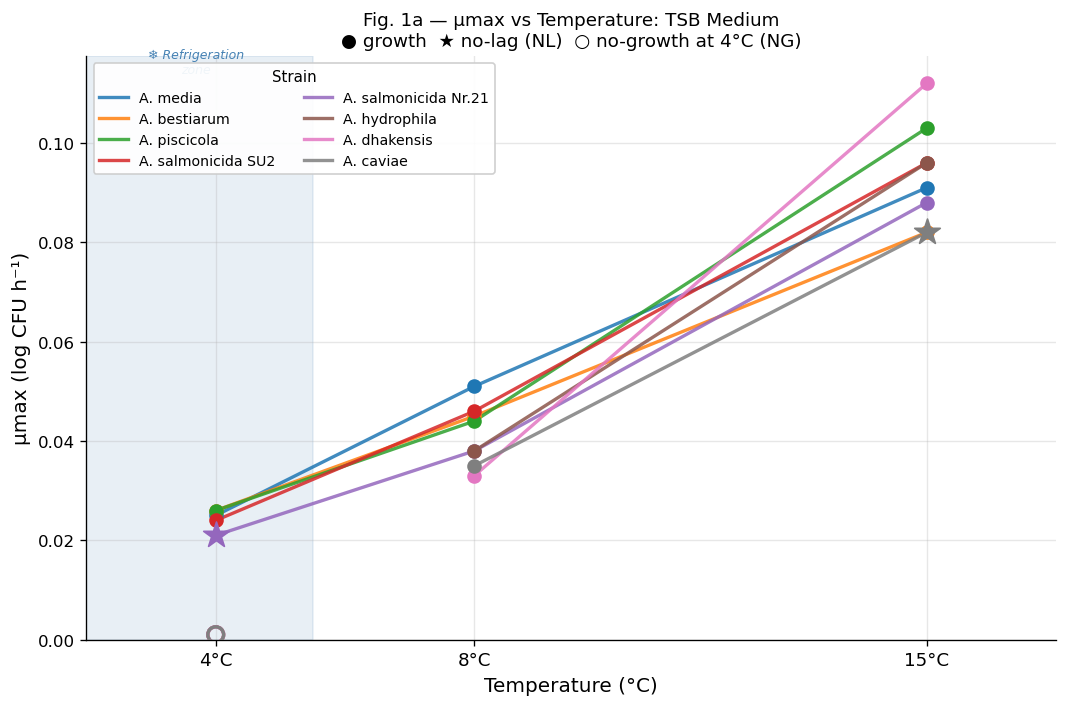

Fig 01a (TSB) saved.


In [10]:
# ── 3-1a. μmax vs Temperature — TSB medium ──────────────────────────────
df_temp = df[(df.experiment == 'Temperature') & (df.medium == 'TSB')].copy()

fig, ax = plt.subplots(figsize=(9, 6))
ax.axvspan(2, 5.5, alpha=0.12, color='steelblue', zorder=0)

for strain in STRAINS_ORDER:
    sub = df_temp[df_temp.strain == strain].sort_values('temperature_C')
    if sub.empty: continue
    growth_rows = sub[sub.growth != 'NG']
    if len(growth_rows) >= 2:
        ax.plot(growth_rows.temperature_C, growth_rows.mu_max,
                color=SC[strain], linewidth=2, alpha=0.85, zorder=2, label=LABELS[strain])
    for _, row in sub.iterrows():
        if row.growth == 'NG':
            ax.scatter(row.temperature_C, 0.001, marker='o', s=90, facecolors='none',
                       edgecolors=SC[strain], linewidths=2, zorder=5)
        elif row.growth == 'NL':
            ax.scatter(row.temperature_C, row.mu_max, marker='*', s=260,
                       color=SC[strain], zorder=5)
        else:
            ax.scatter(row.temperature_C, row.mu_max, marker='o', s=60,
                       color=SC[strain], zorder=4)

ax.legend(loc='upper left', fontsize=8.5, framealpha=0.92, ncol=2,
          title='Strain', title_fontsize=9)
ax.set_xlabel('Temperature (\u00b0C)', fontsize=12)
ax.set_ylabel('\u03bcmax (log CFU h\u207b\u00b9)', fontsize=12)
ax.set_title('Fig. 1a \u2014 \u03bcmax vs Temperature: TSB Medium\n'
             '\u25cf growth  \u2605 no-lag (NL)  \u25cb no-growth at 4\u00b0C (NG)', fontsize=11)
ax.set_xlim(2, 17); ax.set_xticks([4, 8, 15])
ax.set_xticklabels(['4\u00b0C','8\u00b0C','15\u00b0C'], fontsize=11)
ax.set_ylim(bottom=0); ax.spines[['top','right']].set_visible(False)
ymax_val = ax.get_ylim()[1]
ax.text(3.7, ymax_val*0.97, '\u2744 Refrigeration\nzone',
        fontsize=7.5, color='steelblue', ha='center', style='italic')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/01a_kinetics_tsb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 01a (TSB) saved.')


> **Key Insight — Fig 01a (TSB):** μmax increased consistently with temperature across all eight *Aeromonas* strains, confirming temperature as the primary growth driver in TSB medium. Three strains (*A. hydrophila*, *A. dhakensis*, *A. caviae*) showed no growth (NG, ○) at 4°C. Notably, *A. salmonicida* Nr.21 uniquely showed no-lag growth (★) at 4°C — the only strain in TSB where immediate growth onset was observed at refrigeration temperature. *A. caviae* showed no-lag growth (★) at 15°C, reflecting rapid warm-temperature acclimation.


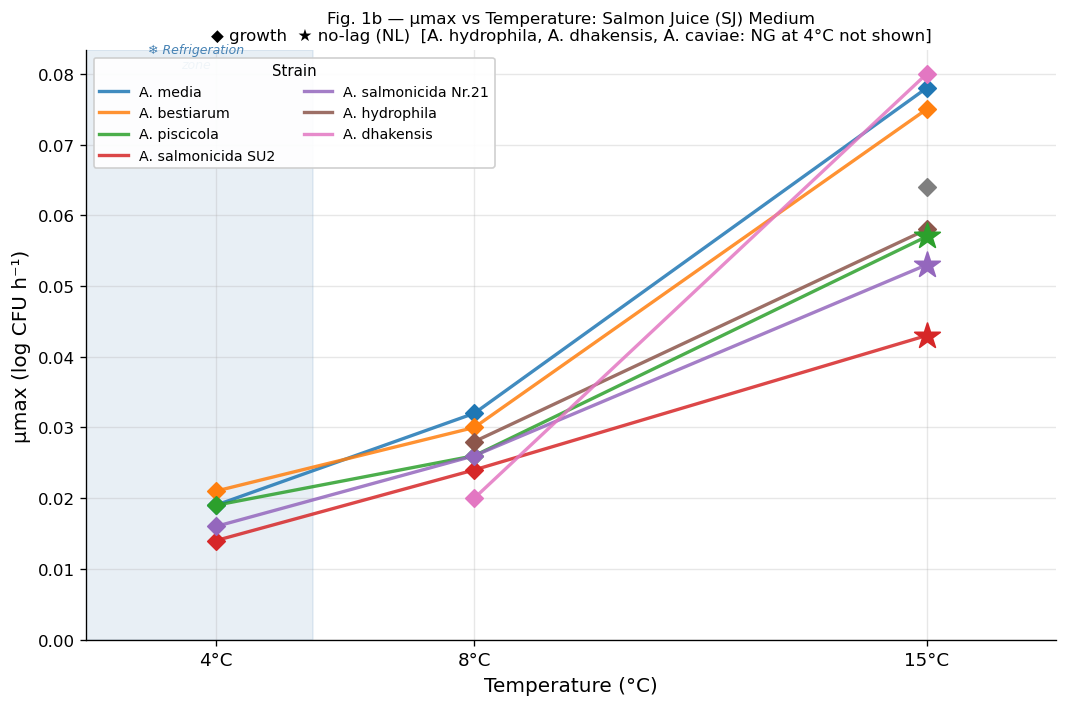

Fig 01b (SJ) saved.


In [ ]:
# ── 3-1b. μmax vs Temperature — SJ (salmon juice) medium ────────
df_sj = df[(df.experiment == 'Temperature') & (df.medium == 'SJ') &
            (df.growth != 'NG')].copy()

fig, ax = plt.subplots(figsize=(9, 6))
ax.axvspan(2, 5.5, alpha=0.12, color='steelblue', zorder=0)

for strain in STRAINS_ORDER:
    sub = df_sj[df_sj.strain == strain].sort_values('temperature_C')
    if sub.empty: continue
    if len(sub) >= 2:
        ax.plot(sub.temperature_C, sub.mu_max, color=SC[strain],
                linewidth=2, alpha=0.85, zorder=2, label=LABELS[strain])
    for _, row in sub.iterrows():
        if row.growth == 'NL':
            ax.scatter(row.temperature_C, row.mu_max, marker='*', s=260,
                       color=SC[strain], zorder=5)
        else:
            ax.scatter(row.temperature_C, row.mu_max, marker='D', s=55,
                       color=SC[strain], zorder=4)

ax.legend(loc='upper left', fontsize=8.5, framealpha=0.92, ncol=2,
          title='Strain', title_fontsize=9)
ax.set_xlabel('Temperature (\u00b0C)', fontsize=12)
ax.set_ylabel('\u03bcmax (log CFU h\u207b\u00b9)', fontsize=12)
ax.set_title('Fig. 1b \u2014 \u03bcmax vs Temperature: Salmon Juice (SJ) Medium\n'
             '\u25c6 growth  \u2605 no-lag (NL)  [A. hydrophila, A. dhakensis, A. caviae: NG at 4\u00b0C not shown]',
             fontsize=10)
ax.set_xlim(2, 17); ax.set_xticks([4, 8, 15])
ax.set_xticklabels(['4\u00b0C','8\u00b0C','15\u00b0C'], fontsize=11)
ax.set_ylim(bottom=0); ax.spines[['top','right']].set_visible(False)
ymax_val = ax.get_ylim()[1]
ax.text(3.7, ymax_val*0.97, '\u2744 Refrigeration\nzone',
        fontsize=7.5, color='steelblue', ha='center', style='italic')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/01b_kinetics_sj.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 01b (SJ) saved.')


> **Key Insight —Fig 01b (SJ):** μmax in salmon juice followed the same temperature-driven trend as TSB but at consistently lower values, confirming food-matrix suppression across all temperatures. Three strains (*A. piscicola*, *A. salmonicida* SU2, *A. salmonicida* Nr.21) showed no-lag growth (★) at 15°C in SJ — compared to only *A. caviae* in TSB at 15°C — suggesting that SJ medium conditions at high temperature favor rapid acclimation in more strains. Direct comparison of Fig. 1a and 1b will inform medium-specific parameters in next step.


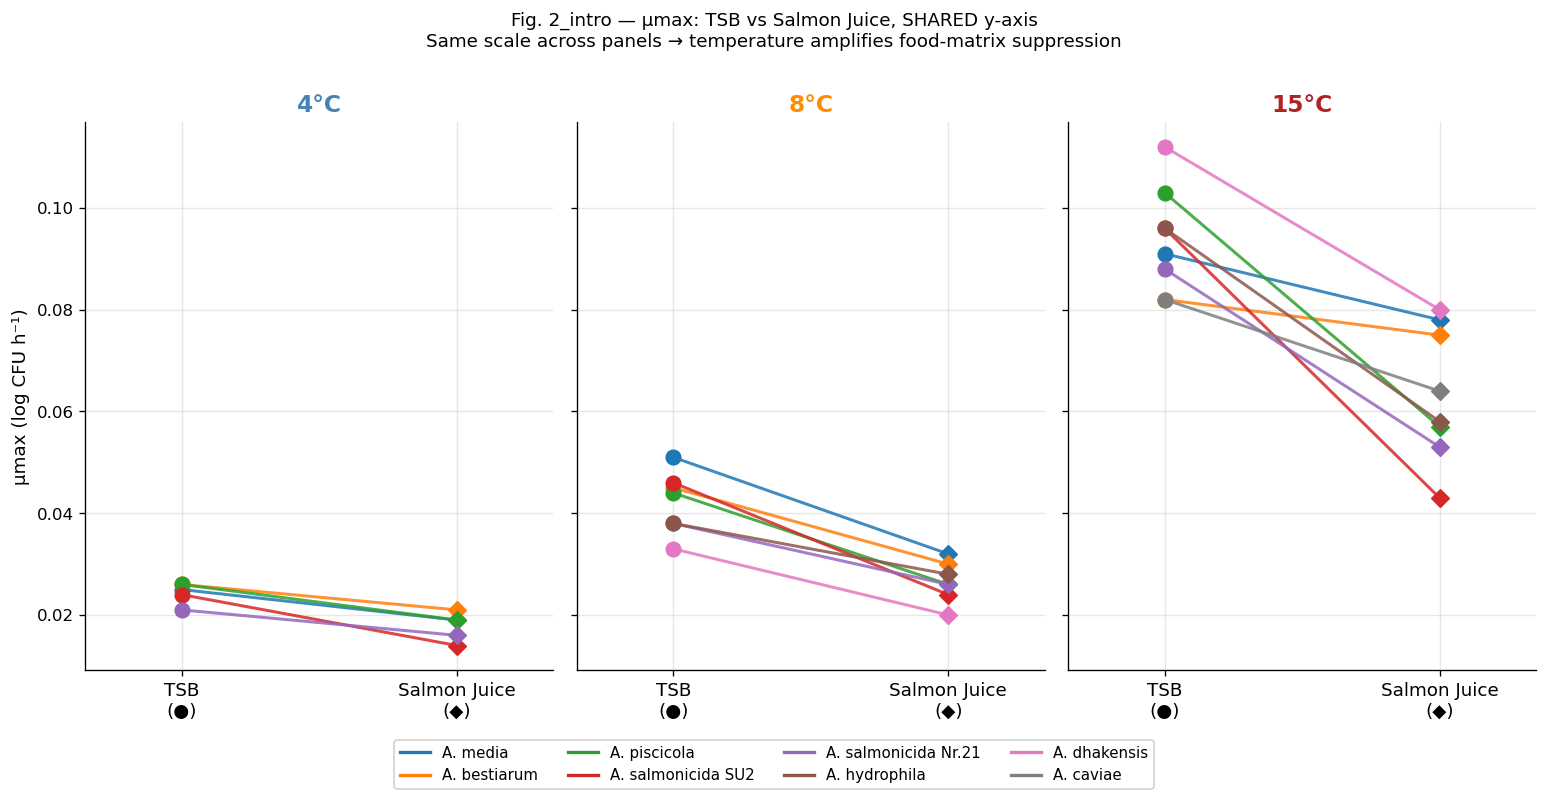

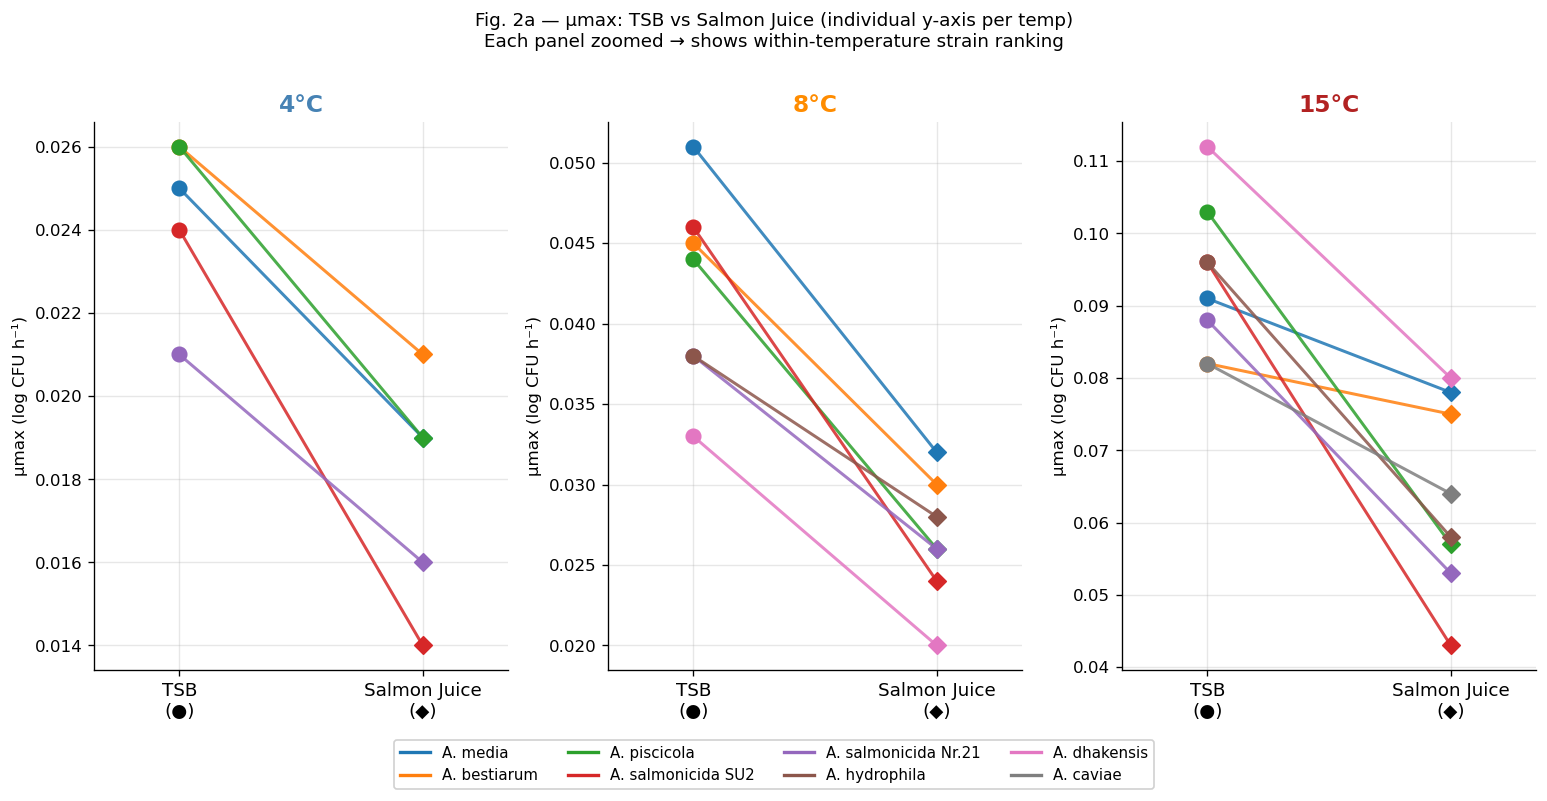

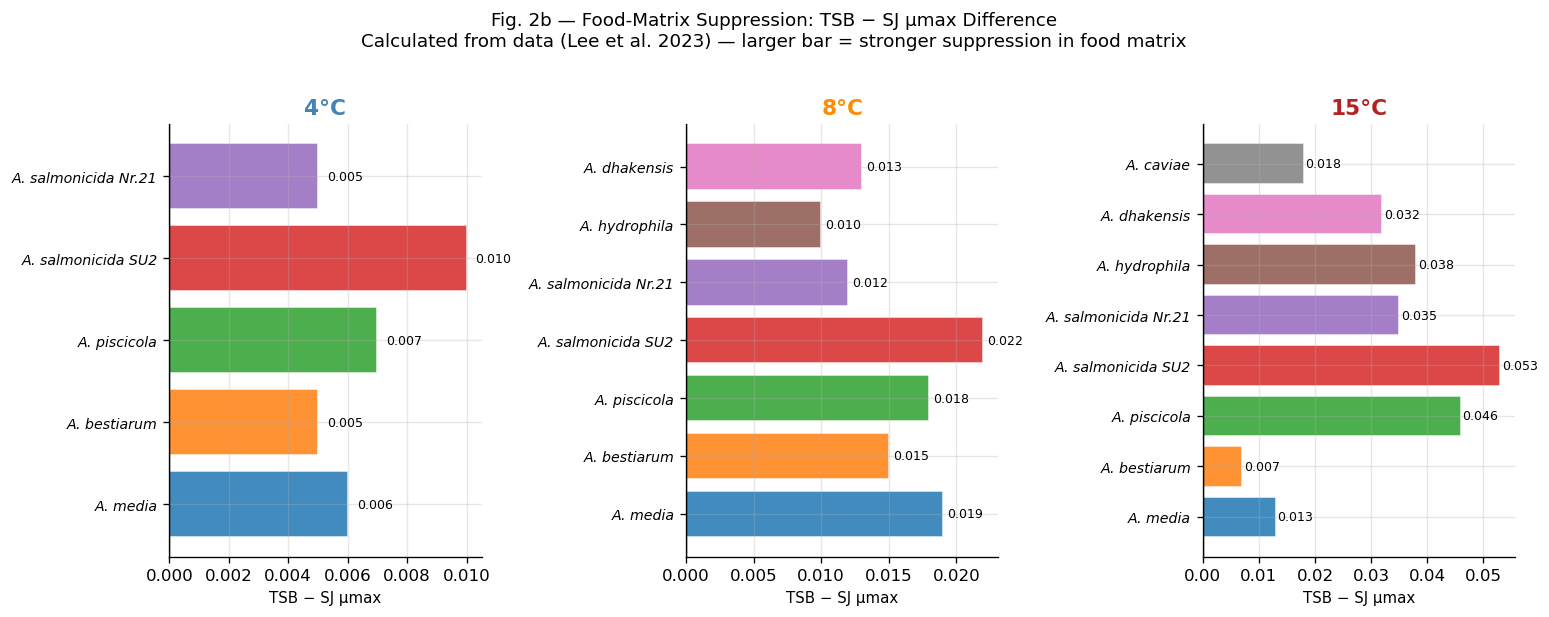

Fig 02 saved (intro + 2a + 2b).


In [ ]:
# ── 3-2. TSB vs SJ comparison : shared-y intro + slope + difference ──────
df_both = df[df.experiment == 'Temperature'].copy()
temps = [4, 8, 15]
temp_colors = {4:'steelblue', 8:'darkorange', 15:'firebrick'}

# ── Fig 2_intro: 3 panels SHARED y-axis — shows temperature amplifies the gap
fig, axes = plt.subplots(1, 3, figsize=(13, 6), sharey=True)
for ax, temp in zip(axes, temps):
    sub = df_both[(df_both.temperature_C==temp) & (df_both.growth!='NG')]
    pivot = sub.pivot_table(index='strain', columns='medium', values='mu_max')
    for strain in STRAINS_ORDER:
        if strain not in pivot.index: continue
        tsb_val = pivot.loc[strain].get('TSB', None)
        sj_val  = pivot.loc[strain].get('SJ',  None)
        if pd.isna(tsb_val) or pd.isna(sj_val): continue
        ax.plot([0,1],[tsb_val,sj_val], color=SC[strain], linewidth=1.8, alpha=0.85)
        ax.scatter(0, tsb_val, marker='o', s=75, color=SC[strain], zorder=4)
        ax.scatter(1, sj_val,  marker='D', s=55, color=SC[strain], zorder=4,
                   label=LABELS[strain])
    ax.set_title(f'{temp}\u00b0C', fontsize=14, fontweight='bold',
                 color=temp_colors[temp])
    ax.set_xticks([0,1])
    ax.set_xticklabels(['TSB\n(\u25cf)','Salmon Juice\n(\u25c6)'], fontsize=11)
    ax.set_xlim(-0.35,1.35)
    if temp==4: ax.set_ylabel('\u03bcmax (log CFU h\u207b\u00b9)', fontsize=11)
    ax.spines[['top','right']].set_visible(False)

handles = [plt.Line2D([0],[0],color=SC[s],linewidth=2,label=LABELS[s]) for s in STRAINS_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5,-0.08), framealpha=0.9)
fig.suptitle('Fig. 2_intro \u2014 \u03bcmax: TSB vs Salmon Juice, SHARED y-axis\n'
             'Same scale across panels \u2192 temperature amplifies food-matrix suppression',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/02_intro_shared_y.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 2a: 3 panels INDIVIDUAL y-axis (zoom per temperature)
fig, axes = plt.subplots(1, 3, figsize=(13, 6), sharey=False)
for ax, temp in zip(axes, temps):
    sub = df_both[(df_both.temperature_C==temp) & (df_both.growth!='NG')]
    pivot = sub.pivot_table(index='strain', columns='medium', values='mu_max')
    for strain in STRAINS_ORDER:
        if strain not in pivot.index: continue
        tsb_val = pivot.loc[strain].get('TSB', None)
        sj_val  = pivot.loc[strain].get('SJ',  None)
        if pd.isna(tsb_val) or pd.isna(sj_val): continue
        ax.plot([0,1],[tsb_val,sj_val], color=SC[strain], linewidth=1.8, alpha=0.85)
        ax.scatter(0, tsb_val, marker='o', s=75, color=SC[strain], zorder=4)
        ax.scatter(1, sj_val,  marker='D', s=55, color=SC[strain], zorder=4)
    ax.set_title(f'{temp}\u00b0C', fontsize=14, fontweight='bold',
                 color=temp_colors[temp])
    ax.set_xticks([0,1])
    ax.set_xticklabels(['TSB\n(\u25cf)','Salmon Juice\n(\u25c6)'], fontsize=11)
    ax.set_xlim(-0.35,1.35)
    ax.set_ylabel('\u03bcmax (log CFU h\u207b\u00b9)', fontsize=10)
    ax.spines[['top','right']].set_visible(False)

fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5,-0.08), framealpha=0.9)
fig.suptitle('Fig. 2a \u2014 \u03bcmax: TSB vs Salmon Juice (individual y-axis per temp)\n'
             'Each panel zoomed \u2192 shows within-temperature strain ranking',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/02a_tsb_vs_sj_individual_y.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 2b: Difference bar chart (TSB - SJ)
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, temp in zip(axes, temps):
    sub = df_both[(df_both.temperature_C==temp) & (df_both.growth!='NG')]
    pivot = sub.pivot_table(index='strain', columns='medium', values='mu_max')
    diffs, colors, names = [], [], []
    for strain in STRAINS_ORDER:
        if strain not in pivot.index: continue
        tsb_val = pivot.loc[strain].get('TSB',None)
        sj_val  = pivot.loc[strain].get('SJ',None)
        if pd.isna(tsb_val) or pd.isna(sj_val): continue
        diffs.append(tsb_val-sj_val); colors.append(SC[strain]); names.append(LABELS[strain])
    y_pos = range(len(diffs))
    bars = ax.barh(y_pos, diffs, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y_pos); ax.set_yticklabels(names, fontsize=8.5, style='italic')
    ax.set_title(f'{temp}\u00b0C', fontsize=13, fontweight='bold', color=temp_colors[temp])
    ax.set_xlabel('TSB \u2212 SJ \u03bcmax', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    for bar, val in zip(bars, diffs):
        ax.text(val+0.0003, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7.5)

fig.suptitle('Fig. 2b \u2014 Food-Matrix Suppression: TSB \u2212 SJ \u03bcmax Difference\n'
             'Calculated from data (Lee et al. 2023) \u2014 larger bar = stronger suppression in food matrix',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/02b_tsb_sj_difference.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 02 saved (intro + 2a + 2b).')


> **Key Insight — Fig 02:** All 8 strains showed higher μmax in TSB than in salmon juice (SJ), with all slope lines pointing downward. The shared-y-axis view (Fig. 2_intro) makes clear that the food-matrix suppression gap grows markedly with temperature — at 4°C strain lines are tightly compressed,  while at 15°C the TSB-SJ spread is far larger (Fig. 2b, data-derived calculation). This pattern highlights that broth-based growth rates may overestimate real-food growth, a consideration when applying these parameters to product shelf-life models. 

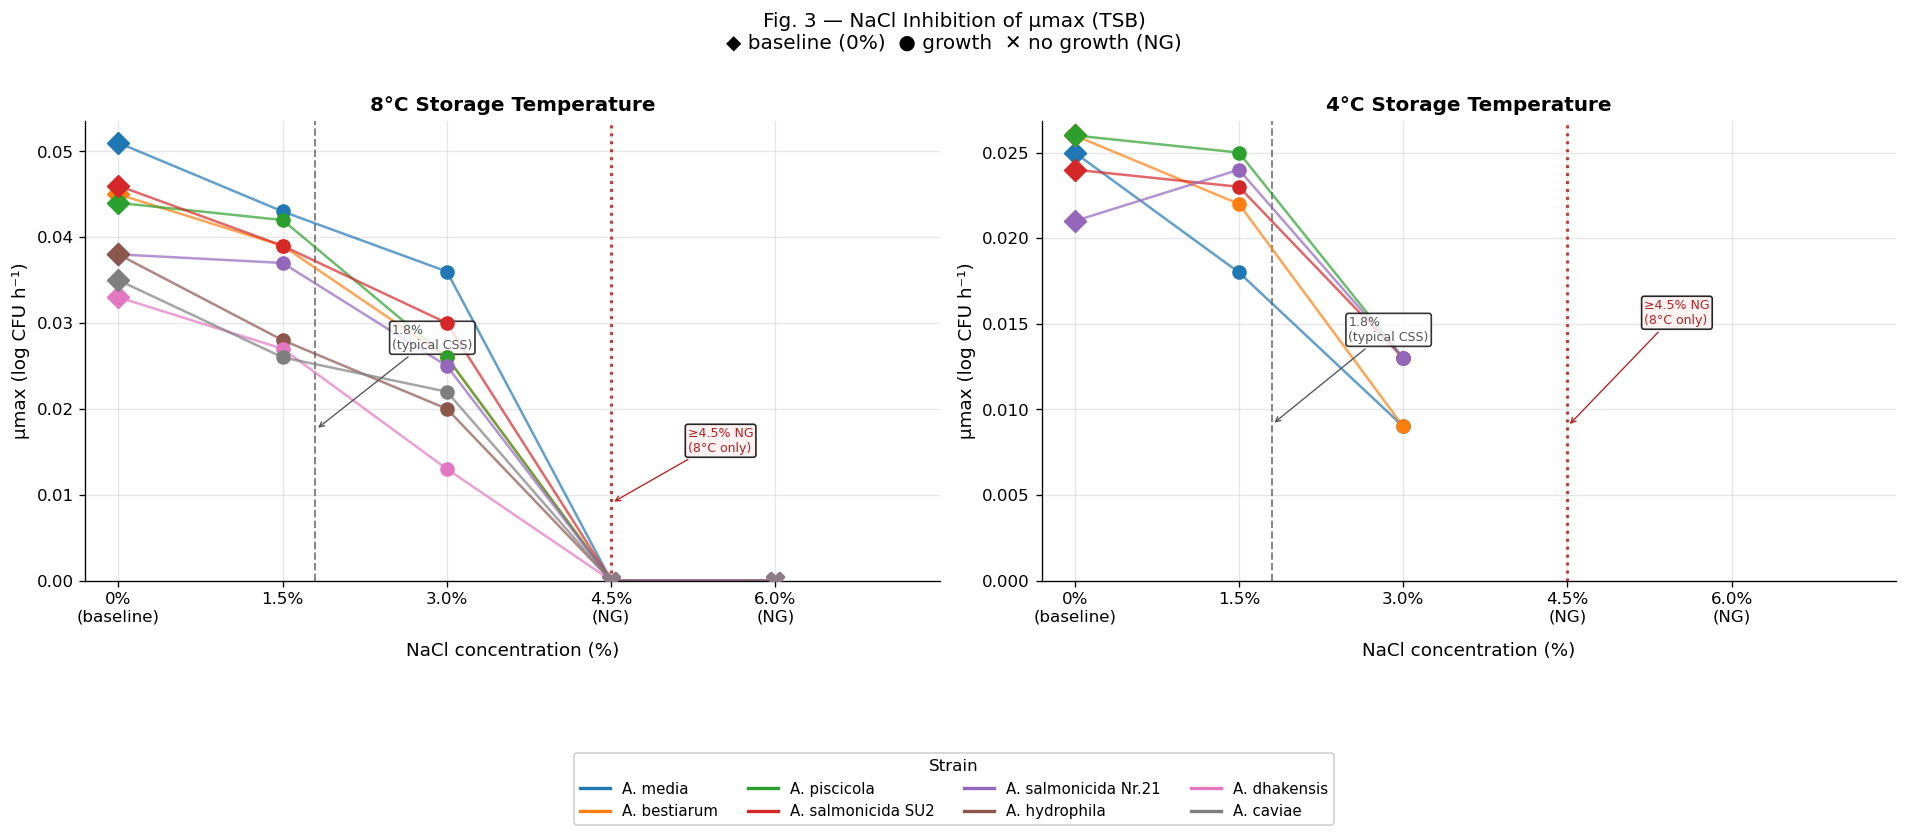

Fig 03 saved (8°C + 4°C panels).


In [11]:
# ── 3-3. NaCl inhibition effect on μmax — 8°C and 4°C  ─────────────────
df_nacl = df[df.experiment=='NaCl'].copy()
df_baseline_8 = df[(df.experiment=='Temperature') & (df.medium=='TSB') &
                   (df.temperature_C==8) & (df.growth!='NG')].copy()
df_baseline_4 = df[(df.experiment=='Temperature') & (df.medium=='TSB') &
                   (df.temperature_C==4) & (df.growth!='NG')].copy()

def nacl_panel(ax, temp_c, df_nacl_t, df_baseline_t, title_suffix, css_text_y=None):
    mid_y = 0.015
    ax.axvline(x=1.8, color='#555555', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.axvline(x=4.5, color='firebrick', linestyle=':', linewidth=1.8, alpha=0.85)
    # css_text_y가 없으면 기본값 사용
    _css_y = css_text_y if css_text_y is not None else mid_y * 1.8
    ax.annotate('1.8%\n(typical CSS)',
                xy=(1.8, _css_y * 0.65), xytext=(2.5, _css_y),
                fontsize=7.5, color='#555555',
                arrowprops=dict(arrowstyle='->', color='#555555', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    ax.annotate('\u22654.5% NG\n(8\u00b0C only)',
                xy=(4.5, mid_y*0.6), xytext=(5.2, mid_y*1.0),
                fontsize=7.5, color='firebrick',
                arrowprops=dict(arrowstyle='->', color='firebrick', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFF0F0', alpha=0.85))
    for strain in STRAINS_ORDER:
        xs, ys = [], []
        b = df_baseline_t[df_baseline_t.strain==strain]
        if not b.empty:
            mu0 = b.mu_max.values[0]
            ax.scatter(0, mu0, marker='D', s=85, color=SC[strain], zorder=5)
            xs.append(0); ys.append(mu0)
        sub_n = df_nacl_t[df_nacl_t.strain==strain].sort_values('NaCl_pct')
        for _, row in sub_n.iterrows():
            if row.growth=='NG':
                ax.scatter(row.NaCl_pct, 0, marker='X', s=110,
                           color=SC[strain], alpha=0.8, zorder=5)
                xs.append(row.NaCl_pct); ys.append(0)
            else:
                ax.scatter(row.NaCl_pct, row.mu_max, marker='o', s=60,
                           color=SC[strain], zorder=4)
                xs.append(row.NaCl_pct); ys.append(row.mu_max)
        if len(xs)>=2:
            ax.plot(xs, ys, color=SC[strain], linewidth=1.5, alpha=0.7,
                    label=LABELS[strain])
    ax.set_xlabel('NaCl concentration (%)', fontsize=11, labelpad=10)
    ax.set_ylabel('\u03bcmax (log CFU h\u207b\u00b9)', fontsize=11)
    ax.set_title(title_suffix, fontsize=12, fontweight='bold')
    ax.set_xlim(-0.3, 7.5)
    ax.set_xticks([0, 1.5, 3.0, 4.5, 6.0])
    ax.set_xticklabels(['0%\n(baseline)','1.5%','3.0%','4.5%\n(NG)','6.0%\n(NG)'])
    ax.set_ylim(bottom=0)
    ax.spines[['top','right']].set_visible(False)

df_nacl_8 = df_nacl[df_nacl.temperature_C==8].copy()
df_nacl_4 = df_nacl[df_nacl.temperature_C==4].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# 8°C: y축 최대 ~0.05이므로 기존 mid_y*1.8=0.027 적절
# 4°C: y축 최대 ~0.026이므로 title과 겹치지 않도록 낮춤 → 0.014
nacl_panel(axes[0], 8, df_nacl_8, df_baseline_8, '8\u00b0C Storage Temperature', css_text_y=0.027)
nacl_panel(axes[1], 4, df_nacl_4, df_baseline_4, '4\u00b0C Storage Temperature', css_text_y=0.014)

handles = [plt.Line2D([0],[0],color=SC[s],linewidth=2,label=LABELS[s]) for s in STRAINS_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.13), framealpha=0.9, title='Strain')
fig.suptitle('Fig. 3 \u2014 NaCl Inhibition of \u03bcmax (TSB)\n'
             '\u25c6 baseline (0%)  \u25cf growth  \u2715 no growth (NG)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)   # legend와 xlabel 겹침 방지
plt.savefig(f'{OUT_DIR}/03_nacl_inhibition_4c_8c.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 03 saved (8°C + 4°C panels).')

> **Key Insight — Fig 03:** At 8°C, NaCl progressively suppressed μmax for all strains, with complete inhibition (NG) at ≥4.5% NaCl (Lee et al. 2023, confirmed in paper). The typical commercial cold-smoked salmon NaCl level (~1.8%) falls within the growth-permissive zone at 8°C, meaning salt alone is insufficient at mild abuse temperatures. At 4°C, growth was already very slow at 0% NaCl, and strains that grew at all (*A. media*, *A. bestiarum*, *A. piscicola*, *A. salmonicida* SU2 and Nr.21) showed further suppression with increasing NaCl — the three NG-at-4°C strains (*A. hydrophila*, *A. dhakensis*, *A. caviae*) show no data at any NaCl level.

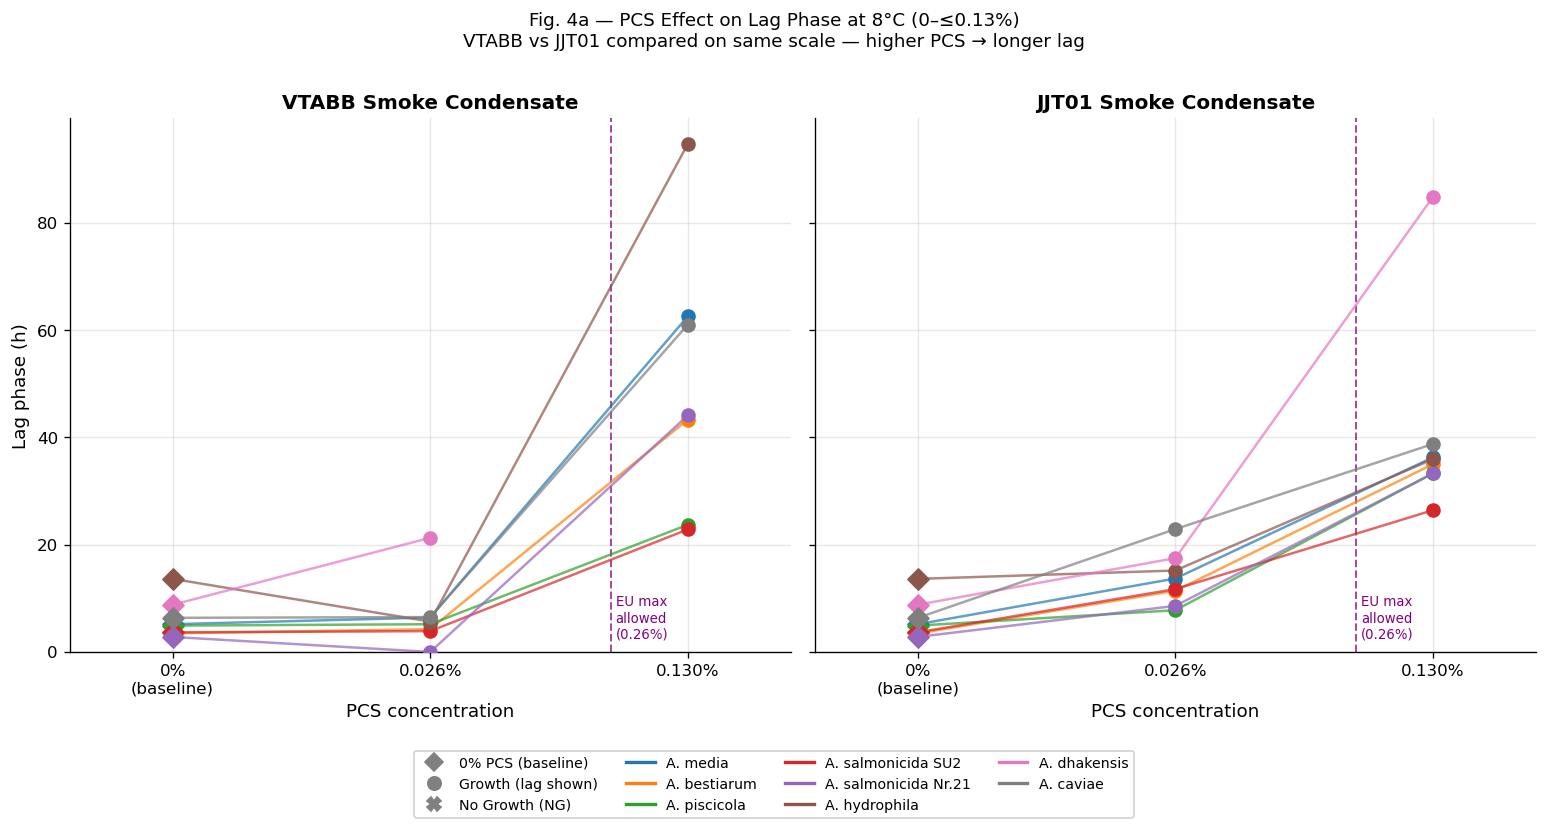

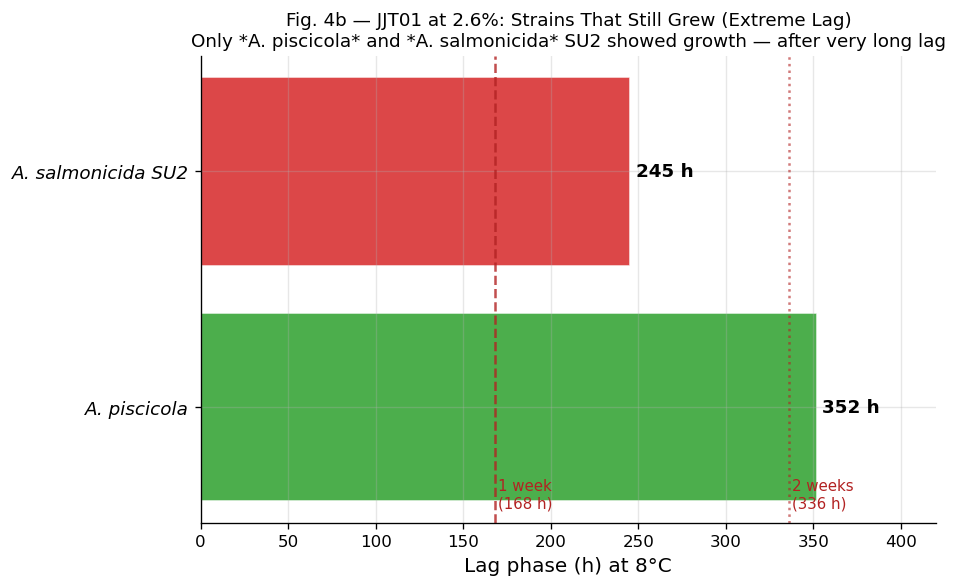

Fig 04 saved (4a main comparison + 4b JJT01 extreme).


In [19]:
# ── 3-4. PCS effect on lag phase — v4 (evenly-spaced x, 4a & 4b) ────────────
df_pcs   = df[df.experiment.isin(['PCS_VTABB','PCS_JJT01'])].copy()
df_pcs_8 = df_pcs[df_pcs.temperature_C==8].copy()
df_base  = df[(df.experiment=='Temperature') & (df.medium=='TSB') &
              (df.temperature_C==8) & (df.growth!='NG')].copy()

# ── Fig 4a: VTABB vs JJT01 at 0, 0.026, 0.130% — EVENLY SPACED x-axis ───────
# Use rank positions [0,1,2] so 0.026% and 0.130% are equally spread (not squished)
x_concs    = [0.0, 0.026, 0.130]
x_labels   = ['0%\n(baseline)', '0.026%', '0.130%']
x_pos      = {c: i for i, c in enumerate(x_concs)}  # 0,1,2

pcs_types  = ['PCS_VTABB', 'PCS_JJT01']
pcs_titles = ['VTABB Smoke Condensate', 'JJT01 Smoke Condensate']

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, pcs_type, title in zip(axes, pcs_types, pcs_titles):
    sub = df_pcs_8[df_pcs_8.experiment==pcs_type]
    # Max-allowed reference at position between 0.026 and 0.130 (0.26% > 0.13%)
    ax.axvline(x=1.7, color='purple', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(1.72, 2, 'EU max\nallowed\n(0.26%)', fontsize=8, color='purple', va='bottom')

    for strain in STRAINS_ORDER:
        xs_p, ys_p = [], []
        # 0% baseline
        b = df_base[df_base.strain==strain]
        if not b.empty and not pd.isna(b.lag_h.values[0]):
            ax.scatter(x_pos[0.0], b.lag_h.values[0], marker='D', s=80,
                       color=SC[strain], zorder=5)
            xs_p.append(x_pos[0.0]); ys_p.append(b.lag_h.values[0])
        # 0.026% and 0.130%
        sub_s = sub[(sub.strain==strain) & (sub.PCS_conc_pct.isin([0.026,0.130]))].sort_values('PCS_conc_pct')
        for _, row in sub_s.iterrows():
            if row.PCS_conc_pct not in x_pos: continue
            if row.growth=='NG':
                ax.scatter(x_pos[row.PCS_conc_pct], 0, marker='X', s=110,
                           color=SC[strain], alpha=0.8, zorder=5)
                xs_p.append(x_pos[row.PCS_conc_pct]); ys_p.append(0)
            elif not pd.isna(row.lag_h):
                ax.scatter(x_pos[row.PCS_conc_pct], row.lag_h, marker='o', s=60,
                           color=SC[strain], zorder=4)
                xs_p.append(x_pos[row.PCS_conc_pct]); ys_p.append(row.lag_h)
        if len(xs_p)>=2:
            ax.plot(xs_p, ys_p, color=SC[strain], linewidth=1.5, alpha=0.7,
                    label=LABELS[strain])

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('PCS concentration', fontsize=11)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_xlim(-0.4, 2.4); ax.set_ylim(bottom=0)
    if pcs_type=='PCS_VTABB': ax.set_ylabel('Lag phase (h)', fontsize=11)
    ax.spines[['top','right']].set_visible(False)

from matplotlib.lines import Line2D
leg_els = [Line2D([0],[0],marker='D',color='gray',linestyle='None',markersize=8,label='0% PCS (baseline)'),
           Line2D([0],[0],marker='o',color='gray',linestyle='None',markersize=8,label='Growth (lag shown)'),
           Line2D([0],[0],marker='X',color='gray',linestyle='None',markersize=8,label='No Growth (NG)')]
strain_els = [Line2D([0],[0],color=SC[s],linewidth=2,label=LABELS[s]) for s in STRAINS_ORDER]
fig.legend(handles=leg_els+strain_els, loc='lower center', ncol=4, fontsize=8.5,
           bbox_to_anchor=(0.5,-0.12), framealpha=0.9)
fig.suptitle('Fig. 4a \u2014 PCS Effect on Lag Phase at 8\u00b0C (0\u2013\u22640.13%)\n'
             'VTABB vs JJT01 compared on same scale \u2014 higher PCS \u2192 longer lag',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/04a_pcs_lag_main.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 4b: JJT01 2.6% extreme case — only strains that grew ─────────────────
jjt01_high = df_pcs_8[(df_pcs_8.experiment=='PCS_JJT01') &
                       (df_pcs_8.PCS_conc_pct==2.6) &
                       (df_pcs_8.growth=='Y')].copy()

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors, bar_lags, bar_labels = [], [], []
for strain in STRAINS_ORDER:
    row = jjt01_high[jjt01_high.strain==strain]
    if row.empty: continue
    bar_lags.append(row.lag_h.values[0])
    bar_colors.append(SC[strain])
    bar_labels.append(LABELS[strain])

bars = ax.barh(range(len(bar_lags)), bar_lags, color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(bar_labels)))
ax.set_yticklabels(bar_labels, fontsize=11, style='italic')
for bar, val in zip(bars, bar_lags):
    ax.text(val+3, bar.get_y()+bar.get_height()/2,
            f'{val:.0f} h', va='center', fontsize=11, fontweight='bold')

ax.axvline(x=168, color='firebrick', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(170, -0.3, '1 week\n(168 h)', fontsize=9, color='firebrick', va='top')
ax.axvline(x=336, color='firebrick', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(338, -0.3, '2 weeks\n(336 h)', fontsize=9, color='firebrick', va='top')

ax.set_xlabel('Lag phase (h) at 8\u00b0C', fontsize=12)
ax.set_title('Fig. 4b \u2014 JJT01 at 2.6%: Strains That Still Grew (Extreme Lag)\n'
             'Only *A. piscicola* and *A. salmonicida* SU2 showed growth \u2014 after very long lag',
             fontsize=11)
ax.set_xlim(0, 420)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/04b_jjt01_2p6_extreme.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 04 saved (4a main comparison + 4b JJT01 extreme).')


> **Key Insight — Fig 04:** Both VTABB and JJT01 smoke condensates extended lag phases relative to the 0% baseline (Fig. 4a), with the extension growing with concentration — this pattern is visible from the data (Lee et al. 2023, Tables C & D). At the extreme JJT01 concentration of 2.6%, only two strains (*A. piscicola* and *A. salmonicida* SU2) showed growth after lag phases of ~352 h and ~245 h respectively (Fig. 4b); all other strains showed no growth. The strain-dependent response observed in the data supports the need for strain-level parameters in the predictive model.

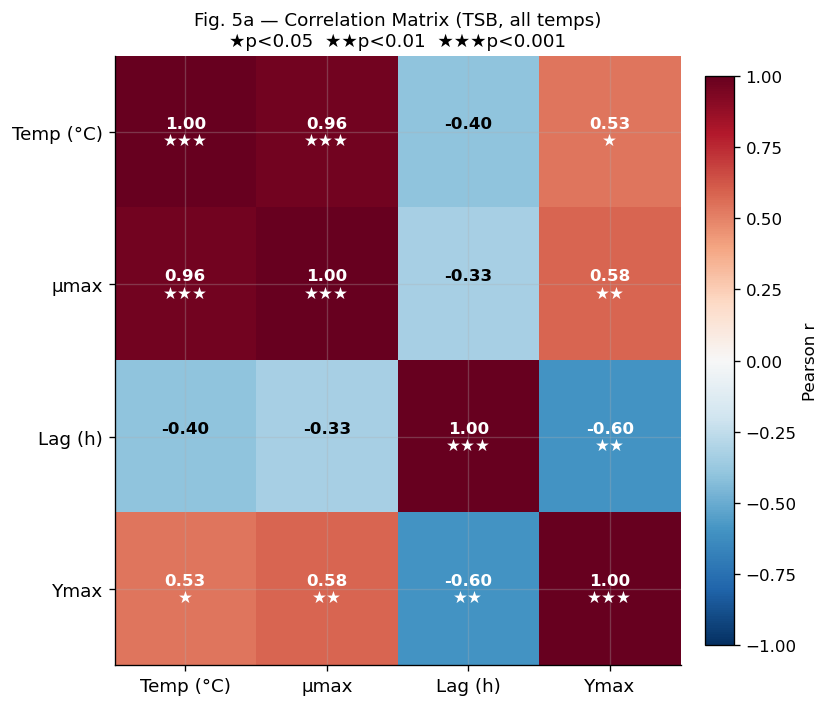

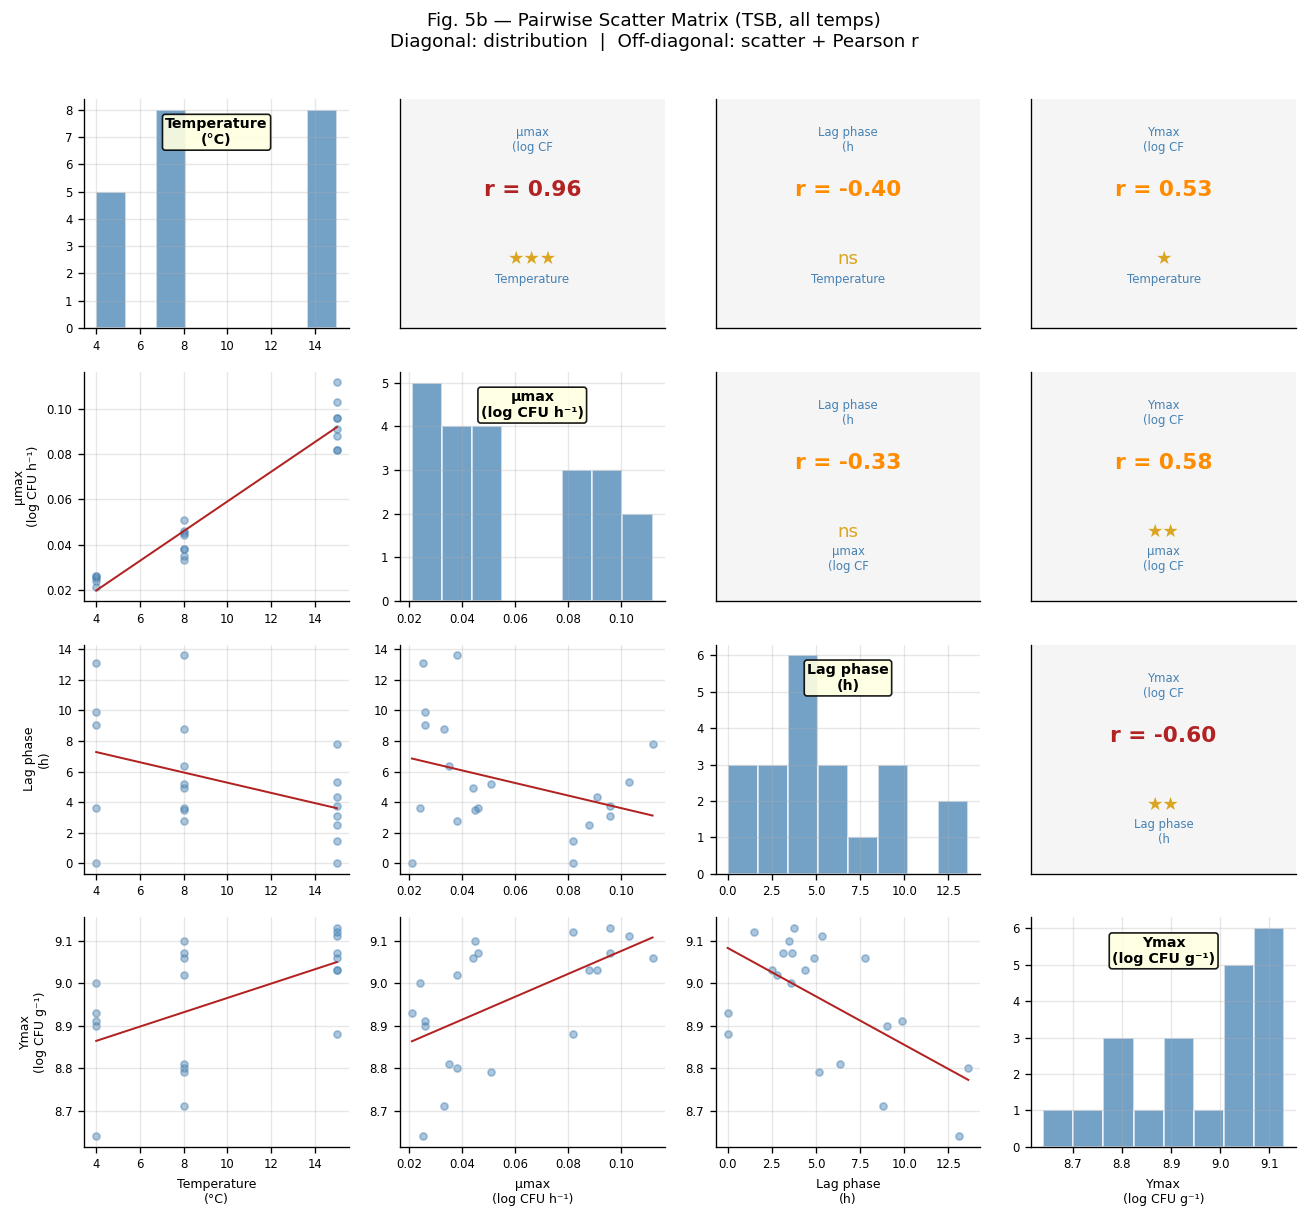

Fig 05 saved (05a heatmap + 05b scatter matrix).


In [ ]:
# ── 3-5. Correlation analysis — heatmap + scatter matrix  ───────────────
import itertools
from scipy import stats

df_corr = df_temp[df_temp.growth != 'NG'][
    ['temperature_C','mu_max','lag_h','ymax']].dropna()
corr_vars   = ['temperature_C', 'mu_max', 'lag_h', 'ymax']
corr_labels = ['Temperature\n(°C)', 'μmax\n(log CFU h⁻¹)',
               'Lag phase\n(h)', 'Ymax\n(log CFU g⁻¹)']
n = len(corr_vars)

# ── Figure A: Seaborn correlation heatmap (easy to read) ─────────────────────
corr_matrix = df_corr[corr_vars].corr()
label_short = ['Temp (°C)', 'μmax', 'Lag (h)', 'Ymax']

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False  # show full matrix
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1,
               aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(label_short, fontsize=11)
ax.set_yticklabels(label_short, fontsize=11)
for i in range(n):
    for j in range(n):
        val = corr_matrix.values[i, j]
        r_val, p_val = stats.pearsonr(df_corr[corr_vars[j]].dropna(),
                                      df_corr[corr_vars[i]].dropna()) if i != j else (1.0, 0)
        stars = '★★★' if p_val < 0.001 else '★★' if p_val < 0.01 else '★' if p_val < 0.05 else ''
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}\n{stars}', ha='center', va='center',
                fontsize=10, color=color, fontweight='bold')
ax.set_title('Fig. 5a \u2014 Correlation Matrix (TSB, all temps)\n'
             '★p<0.05  ★★p<0.01  ★★★p<0.001', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/05a_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure B: Scatter matrix with clearly labeled axes ───────────────────────
fig, axes = plt.subplots(n, n, figsize=(11, 10))
fig.suptitle('Fig. 5b \u2014 Pairwise Scatter Matrix (TSB, all temps)\n'
             'Diagonal: distribution  |  Off-diagonal: scatter + Pearson r',
             fontsize=11, y=1.01)

for r in range(n):
    for c in range(n):
        ax = axes[r][c]
        xv = df_corr[corr_vars[c]].values
        yv = df_corr[corr_vars[r]].values
        mask_v = ~(np.isnan(xv) | np.isnan(yv))
        xv, yv = xv[mask_v], yv[mask_v]

        if r == c:
            ax.hist(xv, bins=8, color='steelblue', alpha=0.75, edgecolor='white')
            # Variable label inside diagonal
            ax.text(0.5, 0.92, corr_labels[c], transform=ax.transAxes,
                    ha='center', va='top', fontsize=8.5, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.9))
        elif r > c:
            ax.scatter(xv, yv, alpha=0.45, s=18, color='steelblue')
            if len(xv) >= 3:
                m, b_coef, *_ = stats.linregress(xv, yv)
                x_line = np.linspace(xv.min(), xv.max(), 50)
                ax.plot(x_line, m * x_line + b_coef, color='firebrick', lw=1.2)
        else:  # upper triangle — show r with context
            if len(xv) >= 3:
                r_val, p_val = stats.pearsonr(xv, yv)
                stars = '★★★' if p_val<0.001 else '★★' if p_val<0.01 else '★' if p_val<0.05 else 'ns'
                color = 'firebrick' if abs(r_val) > 0.6 else ('darkorange' if abs(r_val) > 0.3 else 'black')
                ax.text(0.5, 0.60, f'r = {r_val:.2f}', transform=ax.transAxes,
                        ha='center', va='center', fontsize=13, fontweight='bold', color=color)
                ax.text(0.5, 0.30, stars, transform=ax.transAxes,
                        ha='center', va='center', fontsize=11, color='goldenrod')
                # Show which variables are being compared
                ax.text(0.5, 0.88, corr_labels[c][:12], transform=ax.transAxes,
                        ha='center', va='top', fontsize=7, color='steelblue')
                ax.text(0.5, 0.12, corr_labels[r][:12], transform=ax.transAxes,
                        ha='center', va='bottom', fontsize=7, color='steelblue')
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_facecolor('#F5F5F5')

        ax.tick_params(labelsize=7)
        # Outer axis labels
        if c == 0 and r != 0:
            ax.set_ylabel(corr_labels[r], fontsize=7.5)
        if r == n-1:
            ax.set_xlabel(corr_labels[c], fontsize=7.5)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/05b_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 05 saved (05a heatmap + 05b scatter matrix).')


> **Key Insight — Fig 05:** Temperature and μmax showed the strongest positive correlation (r = 0.96, ★★★), confirming temperature as the dominant kinetic driver (Fig. 5a). Lag phase was negatively correlated with temperature (r = −0.40) while Ymax showed a moderate positive correlation with both temperature and μmax. The scatter matrix (Fig. 5b) shows the pairwise relationships between all four parameters, with variable names clearly labeled in each panel — these correlations directly inform which features carry predictive power in the ML pipeline (Step 2).


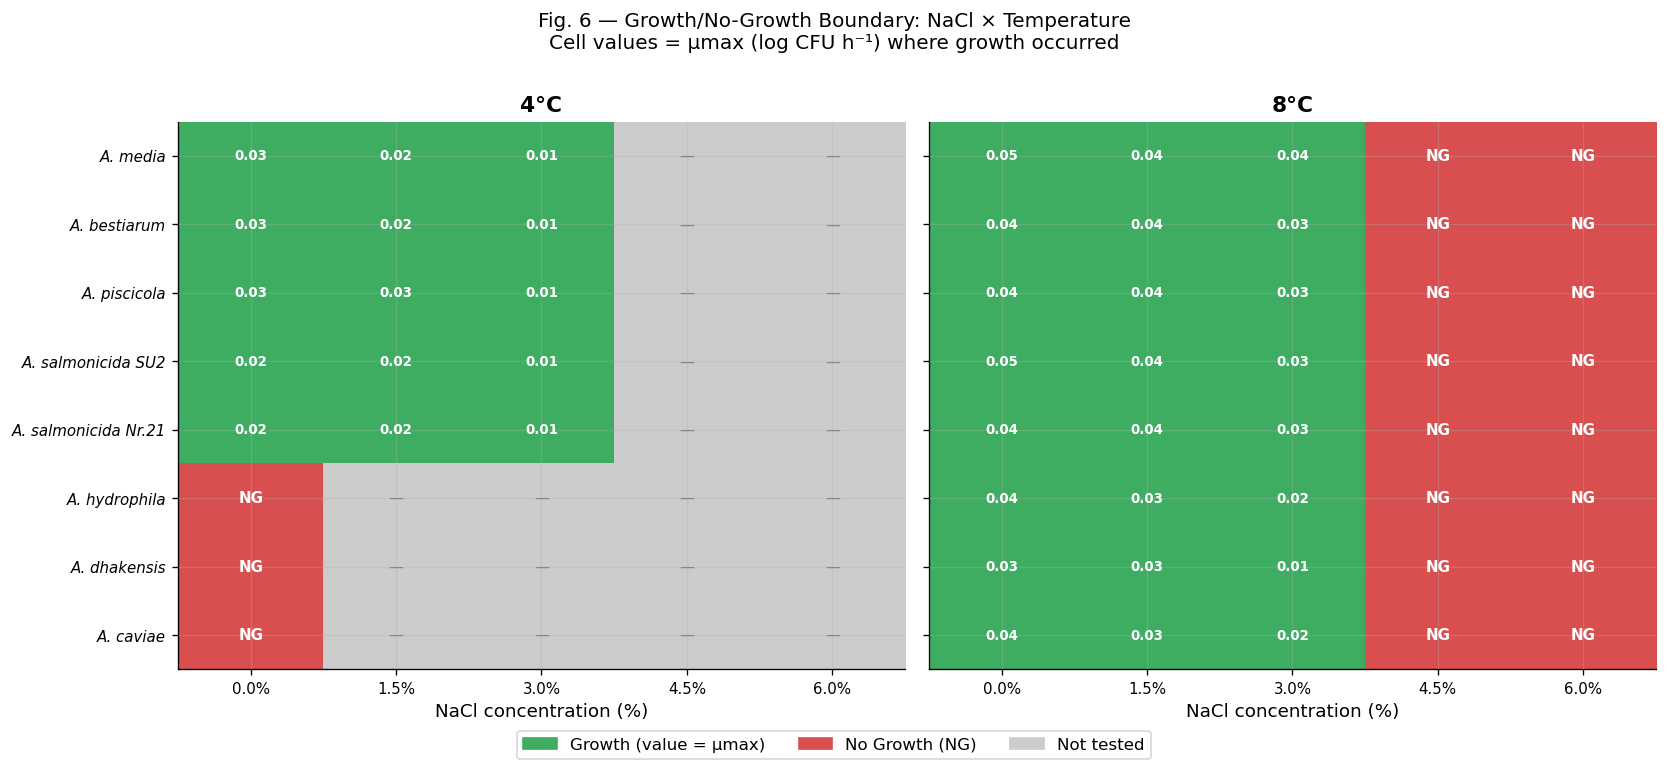

Fig 06 saved.


In [ ]:
# ── 3-6. Growth/No-growth boundary — NaCl heatmap  ─────────────────────
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as mpatches

# Combine Temperature (0% NaCl) + NaCl experiments
df_nacl_all = pd.concat([
    df[(df.experiment == 'Temperature') & (df.medium == 'TSB') & (df.NaCl_pct == 0.0)],
    df[df.experiment == 'NaCl']
], ignore_index=True)

nacl_levels = sorted(df_nacl_all.NaCl_pct.unique())
target_temps = [4, 8]

# Colormap: -1=not tested (grey), 0=NG (red), 1=Growth (green)
cmap = ListedColormap(['#CCCCCC', '#D94F4F', '#3EAD61'])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, temp in zip(axes, target_temps):
    sub = df_nacl_all[df_nacl_all.temperature_C == temp]

    matrix   = np.full((len(STRAINS_ORDER), len(nacl_levels)), -1.0)
    mu_matrix = np.full((len(STRAINS_ORDER), len(nacl_levels)), np.nan)

    for si, strain in enumerate(STRAINS_ORDER):
        for ni, nacl in enumerate(nacl_levels):
            row = sub[(sub.strain == strain) & (sub.NaCl_pct == nacl)]
            if not row.empty:
                r = row.iloc[0]
                if r.growth == 'NG':
                    matrix[si, ni] = 0
                else:
                    matrix[si, ni] = 1
                    mu_matrix[si, ni] = r.mu_max

    # Draw heatmap (no vmin/vmax — norm already handles it)
    im = ax.imshow(matrix, cmap=cmap, norm=norm, aspect='auto')

    # Annotate cells with μmax values
    for si in range(len(STRAINS_ORDER)):
        for ni in range(len(nacl_levels)):
            if not np.isnan(mu_matrix[si, ni]):
                ax.text(ni, si, f'{mu_matrix[si, ni]:.2f}',
                        ha='center', va='center', fontsize=8,
                        fontweight='bold', color='white')
            elif matrix[si, ni] == 0:
                ax.text(ni, si, 'NG', ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
            elif matrix[si, ni] == -1:
                ax.text(ni, si, '—', ha='center', va='center',
                        fontsize=9, color='#888888')

    ax.set_title(f'{temp}°C', fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(nacl_levels)))
    ax.set_xticklabels([f'{n}%' for n in nacl_levels], fontsize=9)
    ax.set_xlabel('NaCl concentration (%)', fontsize=11)
    ax.set_yticks(range(len(STRAINS_ORDER)))
    ax.set_yticklabels([LABELS[s] for s in STRAINS_ORDER],
                       fontsize=9, fontstyle='italic')

# Legend
patch_g  = mpatches.Patch(color='#3EAD61', label='Growth (value = μmax)')
patch_ng = mpatches.Patch(color='#D94F4F', label='No Growth (NG)')
patch_nt = mpatches.Patch(color='#CCCCCC', label='Not tested')
fig.legend(handles=[patch_g, patch_ng, patch_nt], loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Fig. 6 — Growth/No-Growth Boundary: NaCl × Temperature\n'
             'Cell values = μmax (log CFU h⁻¹) where growth occurred',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/06_growth_boundary_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 06 saved.')


> **Key Insight — Fig 06:** At 4°C, five strains (*A. media*, *A. bestiarum*, *A. piscicola*, *A. salmonicida* SU2, Nr.21) continued growing even at 3% NaCl, while three strains (*A. hydrophila*, *A. dhakensis*, *A. caviae*) showed NG at 4°C regardless of NaCl. At 8°C, ≥4.5% NaCl completely inhibited all 8 strains, establishing a clear safety boundary (red NG columns). This growth/no-growth matrix directly informs multi-hurdle product design for cold-smoked RTE seafood.


---
## 4. Secondary Model — Ratkowsky Square-Root Reproduction

The paper uses the **Ratkowsky square-root model** to describe μmax as a function of temperature:

$$\sqrt{\mu_{\max}} = b(T - T_{\min})$$

where *b* is the regression coefficient and *T_min* is the theoretical minimum temperature for growth.  
We reproduce this fit to validate our dataset against the published model.

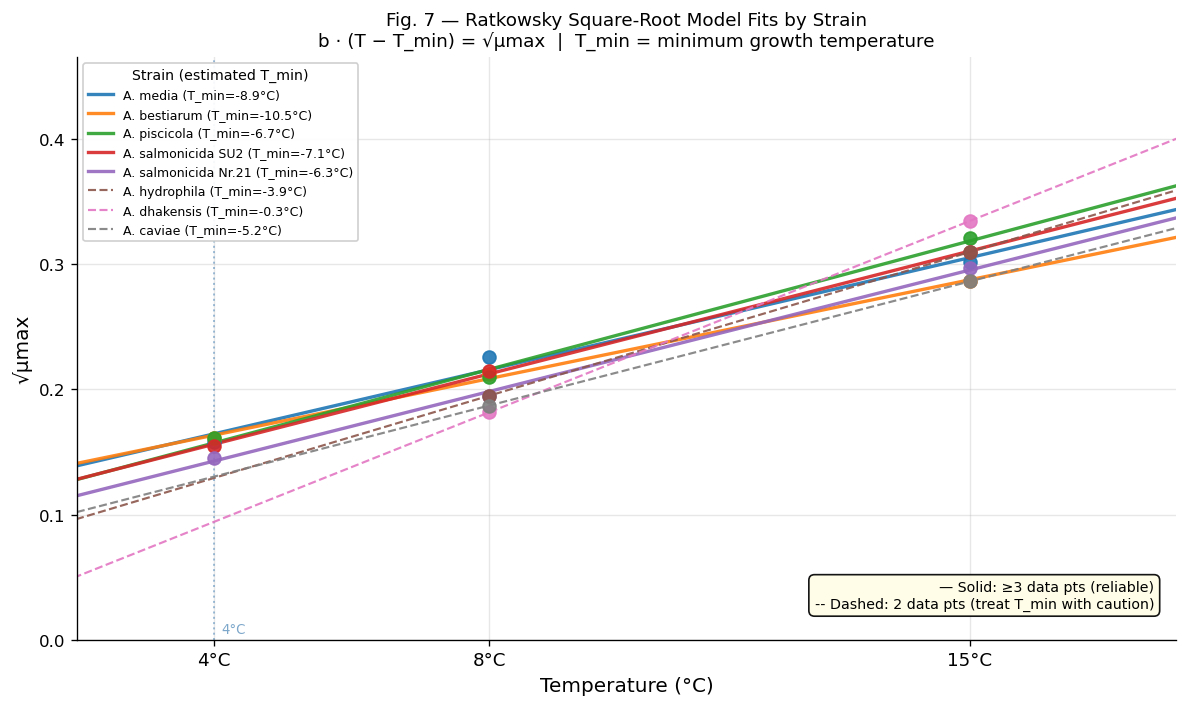


Ratkowsky fitted parameters:
Strain                              b     T_min  n_pts      Quality
--------------------------------------------------------------------
A. media                       0.0128    -8.86°C      3   reliable
A. bestiarum                   0.0113   -10.48°C      3   reliable
A. piscicola                   0.0147    -6.72°C      3   reliable
A. salmonicida SU2             0.0140    -7.14°C      3   reliable
A. salmonicida Nr.21           0.0139    -6.29°C      3   reliable
A. hydrophila                  0.0164    -3.88°C      2   2-pt (dashed)
A. dhakensis                   0.0219    -0.31°C      2   2-pt (dashed)
A. caviae                      0.0142    -5.19°C      2   2-pt (dashed)
Fig 07 saved.


In [ ]:
# ── 4-1. Ratkowsky square-root model — (clean, no overlapping bands) ──────
from scipy.optimize import curve_fit
import warnings

def ratkowsky(T, b, T_min):
    return b * (T - T_min)

df_rat = df[(df.experiment == 'Temperature') & (df.medium == 'TSB') &
             (df.growth.isin(['Y', 'NL']))].copy()
df_rat['sqrt_mu'] = np.sqrt(df_rat.mu_max.clip(lower=0))

T_plot = np.linspace(0, 20, 300)
rat_params = {}

fig, ax = plt.subplots(figsize=(10, 6))

ax.axvline(x=4, color='steelblue', linestyle=':', linewidth=1.2, alpha=0.5)
ax.text(4.1, ax.get_ylim()[1] if False else 0.005, '4\u00b0C', fontsize=8,
        color='steelblue', alpha=0.7)

for strain in STRAINS_ORDER:
    sub = df_rat[df_rat.strain == strain].dropna(subset=['temperature_C','sqrt_mu'])
    if len(sub) < 2: continue

    T_data  = sub.temperature_C.values
    sq_data = sub.sqrt_mu.values
    ax.scatter(T_data, sq_data, color=SC[strain], s=60, zorder=5, alpha=0.9)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            popt, pcov = curve_fit(ratkowsky, T_data, sq_data, p0=[0.02, -2])
        b_fit, Tmin_fit = popt
        rat_params[strain] = {'b': b_fit, 'T_min': Tmin_fit, 'n_pts': len(sub)}
        y_plot = np.clip(ratkowsky(T_plot, *popt), 0, None)

        is_reliable = len(sub) >= 3
        lbl = LABELS[strain] + ' (T_min=' + f'{Tmin_fit:.1f}' + '\u00b0C)'
        ax.plot(T_plot, y_plot, color=SC[strain],
                linewidth=2.0 if is_reliable else 1.3,
                linestyle='-' if is_reliable else '--',
                alpha=0.90, label=lbl)

    except Exception:
        pass

ax.legend(loc='upper left', fontsize=7.5, framealpha=0.92, ncol=1,
          title='Strain (estimated T_min)', title_fontsize=8.5)

# Reliability note (compact)
ax.text(0.98, 0.05,
        '\u2014 Solid: \u22653 data pts (reliable)\n'
        '-- Dashed: 2 data pts (treat T_min with caution)',
        transform=ax.transAxes, fontsize=8.5, va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFFDE7', alpha=0.92))

ax.set_xlabel('Temperature (\u00b0C)', fontsize=12)
ax.set_ylabel('\u221aμmax', fontsize=12)
ax.set_title('Fig. 7 \u2014 Ratkowsky Square-Root Model Fits by Strain\n'
             'b \u00b7 (T \u2212 T_min) = \u221aμmax  |  T_min = minimum growth temperature',
             fontsize=11)
ax.set_xlim(2, 18)
ax.set_xticks([4, 8, 15])
ax.set_xticklabels(['4\u00b0C', '8\u00b0C', '15\u00b0C'], fontsize=11)
ax.set_ylim(bottom=0)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/07_ratkowsky_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# Print parameters table
print('\nRatkowsky fitted parameters:')
print(f'{"Strain":<28} {"b":>8} {"T_min":>9} {"n_pts":>6} {"Quality":>12}')
print('-' * 68)
for s, p in rat_params.items():
    qual = 'reliable' if p['n_pts'] >= 3 else '2-pt (dashed)'
    print(f'{LABELS[s]:<28} {p["b"]:>8.4f} {p["T_min"]:>8.2f}\u00b0C {p["n_pts"]:>6}   {qual}')
print('Fig 07 saved.')


> **Key Insight — Fig 07:** The Ratkowsky square-root model fitted well for strains with data at all three temperatures (solid lines with T_min shown in legend), while strains with only two data points yield unreliable T_min estimates (dashed lines — treat with caution). Estimated minimum growth temperatures (T_min) for well-fitted strains ranged from approximately −6°C to −10°C, suggesting theoretical growth potential well below standard refrigeration — reinforcing the need for multi-hurdle control. These b and T_min parameters serve as core secondary-model features for the ML pipeline in Step 2.


---
## 5. Dataset Scope — Note on ComBase

ComBase data integration was evaluated but excluded from this project scope.  
The current model is trained exclusively on the Lee et al. (2023) dataset (n=118).  
Generalisation beyond this experimental range should be validated against independent data.


---
## Note: Dataset Scope for Step 2 & 3

The master CSV contains **141 rows total** (all experimental conditions including no-growth observations).

| Subset | Rows | Condition | Used in |
|--------|------|-----------|--------|
| growth = Y | 113 | Confirmed growth, kinetic parameters measured | Step 2 ML, Step 3 SHAP |
| growth = NL | 5 | No-lag growth (immediate onset), μmax measured | Step 2 ML, Step 3 SHAP |
| growth = NG | 23 | No growth (NaCl 16 + Temperature 4°C 7) — μmax = NaN | **Excluded** from ML |
| **ML dataset** | **118** | growth ∈ {Y, NL}, all targets non-null | Step 2 & 3 |

> NG rows carry critical biological information (growth/no-growth boundary, Chart 06) and are fully used in EDA. 
They are excluded from Step 2 regression because μmax, lag, and Ymax are undefined when no growth occurs — not a data loss, but a scope decision.

---
## 6. Step 1 Summary & Next Steps

### What we accomplished
| Task | Status |
|---|---|
| Data entry from Supplementary Tables A–D | ✅ |
| Master CSV saved | ✅ `outputs/aeromonas_kinetics_master.csv` |
| Sanity checks vs. published values | ✅ |
| EDA: temperature, media, NaCl, PCS effects | ✅ |
| Ratkowsky model reproduction | ✅ `outputs/ratkowsky_parameters.csv` |
| Dataset scope documented | ✅ n=118, generalisation limits noted |

### Immediate next steps
1. **Step 2 notebook** — ML benchmark (Random Forest / XGBoost) vs. Baranyi/Ratkowsky
2. **Step 3 notebook** — SHAP analysis + feature importance
3. **Step 4 notebook** — Streamlit app prototype

### Dataset limitations (important for README)
- Small-N: ~140 observations with growth from our lab data
- 3 temperatures only → limited for temperature response curves
- `Leave-one-strain-out` cross-validation is required — **never use random split**
- ML complements, not replaces, mechanistic models

In [23]:
# ── Final output summary ─────────────────────────────────────────────────────
print('='*55)
print('STEP 1 COMPLETE')
print('='*55)
print(f'  Master dataset : {len(df)} rows, {df.shape[1]} columns')
print(f'  Strains        : {df.strain.nunique()}')
print(f'  Experiments    : {df.experiment.value_counts().to_dict()}')
print(f'  μmax range     : {df.mu_max.min():.3f} – {df.mu_max.max():.3f} h⁻¹')
print(f'  Lag range      : {df.lag_h.min():.1f} – {df.lag_h.max():.1f} h')
print(f'  Ymax range     : {df.ymax.min():.2f} – {df.ymax.max():.2f} log CFU/g')
print()
print('Output files:')
for f_out in sorted(os.listdir(OUT_DIR)):
    print(f'  outputs/{f_out}')

# ── Confirm CSV saved (prerequisite for Step 2, 3, 4) ────────────────────────
csv_path = Path(OUT_DIR) / 'aeromonas_kinetics_master.csv'
if csv_path.exists():
    print(f'\n✓ Prerequisite met — {csv_path} exists ({len(df)} rows)')
    print('✓ Ready to run: Step 2 → Step 3 → Step 4')
else:
    df.to_csv(csv_path, index=False)
    print(f'\n✓ Master CSV saved: {csv_path} ({len(df)} rows)')
    print('✓ Ready to run: Step 2 → Step 3 → Step 4')


STEP 1 COMPLETE
  Master dataset : 141 rows, 15 columns
  Strains        : 8
  Experiments    : {'Temperature': 48, 'NaCl': 42, 'PCS_JJT01': 28, 'PCS_VTABB': 23}
  μmax range     : 0.004 – 0.112 log CFU/h
  Lag range      : 0.0 – 351.8 h
  Ymax range     : 7.88 – 9.30 log CFU/g

Output files:
  outputs/01a_kinetics_tsb.png
  outputs/01b_kinetics_sj.png
  outputs/02_intro_shared_y.png
  outputs/02a_tsb_vs_sj_individual_y.png
  outputs/02b_tsb_sj_difference.png
  outputs/03_nacl_inhibition_4c_8c.png
  outputs/04a_pcs_lag_main.png
  outputs/04b_jjt01_2p6_extreme.png
  outputs/05a_correlation_heatmap.png
  outputs/05b_scatter_matrix.png
  outputs/06_growth_boundary_improved.png
  outputs/07_ratkowsky_v3.png
  outputs/aeromonas_kinetics_master.csv
